
# Chartmetric API — Pilotos 1 y 2

Objetivo: construir trayectorias digitales mensuales de artistas hasta **2026-03-31 inclusive**, usando sólo métricas transparentes de las plataformas originales.

## Fan Stats

Endpoint: `GET /api/artist/{id}/stat/{source}`

Se consulta **sin `field`** para inspeccionar los campos default de cada source.

Sources y variables objetivo:

- `spotify`: `followers`, `listeners`
- `twitter`: `followers`
- `youtube_channel`: `subscribers`, `views`
- `youtube_artist`: `monthly_views`
- `instagram`: `followers`
- `tiktok`: `followers`, `likes`

Son **6 requests máximos por artista**. El código pide desde una fecha deliberadamente temprana hasta `2026-03-31`; si Chartmetric dispone de menos historia, se conserva únicamente lo que devuelve.

## Playlist Evolution

Endpoint: `GET /api/playlist/by/artist/{id}/evolution`

La documentación actual lo define como una serie diaria y no documenta parámetros de fecha ni paginación. Por eso el piloto realiza **una sola llamada por artista** y luego inspecciona el rango temporal efectivamente devuelto.

Se conservan:

- Spotify: `playlist_count`, `ed_playlist_count`, `playlist_total_reach`, `ed_playlist_total_reach`
- YouTube: `playlist_count`, `ed_playlist_count`, `playlist_total_reach`, `ed_playlist_total_reach`
- Amazon: `playlist_count`, `ed_playlist_count`

## Regla central para ahorrar requests

Antes de llamar a la API, cada función verifica:

1. si la respuesta cruda ya existe en el cache local;
2. si el log registra el request como completado;
3. sólo si no existe ninguna de esas dos evidencias, llama a Chartmetric.

La respuesta cruda se guarda **antes de parsearla**. Así, si aparece un error local después de una descarga exitosa, se puede re-procesar sin repetir el request.

El archivo analítico acumulado sigue siendo uno solo: `chartmetric_raw_long.rds`. El cache crudo es un archivo técnico separado que protege las descargas ya realizadas.


In [1]:

# PAQUETES

paquetes <- c("httr", "jsonlite", "data.table", "lubridate")

faltan <- paquetes[!paquetes %in% rownames(installed.packages())]

if (length(faltan) > 0) {
  install.packages(faltan)
}

library(httr)
library(jsonlite)
library(data.table)
library(lubridate)



Adjuntando el paquete: 'lubridate'


The following objects are masked from 'package:data.table':

    hour, isoweek, mday, minute, month, quarter, second, wday, week,
    yday, year


The following objects are masked from 'package:base':

    date, intersect, setdiff, union




## 1. Configuración

In [2]:
# ============================================================
# CONFIGURACIÓN GENERAL
# ============================================================

BASE_URL <- "https://api.chartmetric.com"

# Período definitivo para las nuevas extracciones.
FAN_SINCE <- as.Date("2021-01-01")
END_DATE <- as.Date("2026-03-31")

FAN_SOURCES <- c(
  "spotify",
  "twitter",
  "youtube_channel",
  "youtube_artist",
  "instagram",
  "tiktok"
)

TARGET_FAN_METRICS <- list(
  spotify         = c("followers", "listeners"),
  twitter         = c("followers"),
  youtube_channel = c("subscribers", "views"),
  youtube_artist  = c("monthly_views"),
  instagram       = c("followers"),
  tiktok          = c("followers", "likes")
)

TARGET_PLAYLIST_METRICS <- list(
  spotify = c(
    "playlist_count",
    "ed_playlist_count",
    "playlist_total_reach",
    "ed_playlist_total_reach"
  ),
  youtube = c(
    "playlist_count",
    "ed_playlist_count",
    "playlist_total_reach",
    "ed_playlist_total_reach"
  ),
  amazon = c(
    "playlist_count",
    "ed_playlist_count"
  )
)

OUT_DIR <- "chartmetric_pilotos"

dir.create(
  OUT_DIR,
  showWarnings = FALSE,
  recursive = TRUE
)

# ------------------------------------------------------------
# Archivos LEGACY
# Se conservan intactos.
# ------------------------------------------------------------

DATA_FILE <- file.path(
  OUT_DIR,
  "chartmetric_raw_long.rds"
)

RAW_RESPONSE_FILE <- file.path(
  OUT_DIR,
  "chartmetric_raw_responses.rds"
)

# ------------------------------------------------------------
# Log general
# ------------------------------------------------------------

LOG_FILE <- file.path(
  OUT_DIR,
  "chartmetric_request_log.csv"
)

# ------------------------------------------------------------
# Nueva arquitectura
# Un archivo por request
# ------------------------------------------------------------

RAW_REQUEST_DIR <- file.path(
  OUT_DIR,
  "raw_requests_2021_2026"
)

MONTHLY_REQUEST_DIR <- file.path(
  OUT_DIR,
  "monthly_requests_2021_2026"
)

dir.create(
  RAW_REQUEST_DIR,
  showWarnings = FALSE,
  recursive = TRUE
)

dir.create(
  MONTHLY_REQUEST_DIR,
  showWarnings = FALSE,
  recursive = TRUE
)

# Dataset mensual consolidado.
MONTHLY_FILE <- file.path(
  OUT_DIR,
  "chartmetric_monthly_2021_2026.rds"
)

cat(
  "Período:",
  format(FAN_SINCE),
  "a",
  format(END_DATE),
  "\n"
)

cat(
  "Raw legacy:",
  DATA_FILE,
  "\n"
)

cat(
  "Requests crudos nuevos:",
  RAW_REQUEST_DIR,
  "\n"
)

cat(
  "Requests mensuales nuevos:",
  MONTHLY_REQUEST_DIR,
  "\n"
)

cat(
  "Mensual consolidado:",
  MONTHLY_FILE,
  "\n"
)

Período: 2021-01-01 a 2026-03-31 
Raw legacy: chartmetric_pilotos/chartmetric_raw_long.rds 
Requests crudos nuevos: chartmetric_pilotos/raw_requests_2021_2026 
Requests mensuales nuevos: chartmetric_pilotos/monthly_requests_2021_2026 
Mensual consolidado: chartmetric_pilotos/chartmetric_monthly_2021_2026.rds 


## 2. Archivo maestro de artistas

In [3]:

# ARCHIVO MAESTRO: dataset_raw_concat_7000

artist_candidates <- c(
  "dataset_raw_concat_7000.csv"
)

existing_candidates <- artist_candidates[file.exists(artist_candidates)]

ARTIST_FILE <- if (length(existing_candidates) > 0) {
  existing_candidates[1]
} else {
  NA_character_
}

load_artist_catalog <- function(path = ARTIST_FILE) {

  if (is.na(path) || !file.exists(path)) {
    message(
      "No encontré dataset_raw_concat_7000 en el working directory. ",
      "Podés definir ARTIST_FILE manualmente más adelante."
    )
    return(data.table())
  }

  x <- fread(
    path,
    select = c(
      "chartmetric_id",
      "artist_name",
      "cm_artist_rank"
    )
  )

  x[, ID := as.character(chartmetric_id)]

  x <- x[
    ,
    .(
      ID,
      artist_name,
      cm_artist_rank
    )
  ]

  unique(x, by = "ID")
}

ARTISTS <- load_artist_catalog()

if (nrow(ARTISTS) > 0) {
  cat("Artistas cargados:", nrow(ARTISTS), "\n")
  print(head(ARTISTS))
}


Artistas cargados: 7000 
       ID   artist_name cm_artist_rank
   <char>        <char>          <int>
1: 214945     Bad Bunny              4
2:   2762  Taylor Swift              1
3:   3501    Bruno Mars              2
4:   3479 Justin Bieber              3
5:   3852    The Weeknd              7
6:   3380         Drake              6


## 3. Autenticación

In [4]:

# AUTENTICACIÓN
# Reutiliza el access token hasta que falte aproximadamente 1 minuto para vencer.

.cm_auth <- new.env(parent = emptyenv())
.cm_auth$token <- NULL
.cm_auth$expires_at <- as.POSIXct(NA)

get_access_token <- function(force = FALSE) {

  refresh_token <- Sys.getenv("CHARTMETRIC_REFRESH_TOKEN")

  if (refresh_token == "") {
    stop(
      "Falta CHARTMETRIC_REFRESH_TOKEN en .Renviron. ",
      "Agregalo y reiniciá el kernel de R."
    )
  }

  ahora <- Sys.time()

  vigente <- (
    !force &&
    !is.null(.cm_auth$token) &&
    !is.na(.cm_auth$expires_at) &&
    ahora < (.cm_auth$expires_at - 60)
  )

  if (vigente) {
    return(.cm_auth$token)
  }

  resp <- POST(
    paste0(BASE_URL, "/api/token"),
    body = list(refreshtoken = refresh_token),
    encode = "json",
    timeout(60)
  )

  status <- status_code(resp)
  texto <- content(resp, as = "text", encoding = "UTF-8")

  if (status != 200) {
    stop(
      "No se pudo obtener access token. HTTP ",
      status,
      "\n",
      substr(texto, 1, 1000)
    )
  }

  body <- fromJSON(
    texto,
    simplifyVector = TRUE
  )

  if (is.null(body$token) || is.null(body$expires_in)) {
    stop("La respuesta de autenticación no tiene la estructura esperada.")
  }

  .cm_auth$token <- body$token
  .cm_auth$expires_at <- ahora + as.numeric(body$expires_in)

  cat(
    "Autenticación OK. Access token obtenido; no se muestra.\n"
  )

  invisible(.cm_auth$token)
}


In [5]:

# PRUEBA DE VIGENCIA DE LA CUENTA/API
# No descarga datos de artistas.

get_access_token(force = TRUE)


Autenticación OK. Access token obtenido; no se muestra.


## 4. Helpers, persistencia, cache y log

In [6]:

# HELPERS BÁSICOS

scalar_chr <- function(x) {
  if (is.null(x) || length(x) == 0) {
    return(NA_character_)
  }

  as.character(
    unlist(
      x,
      recursive = TRUE,
      use.names = FALSE
    )[1]
  )
}

scalar_num <- function(x) {
  if (is.null(x) || length(x) == 0) {
    return(NA_real_)
  }

  suppressWarnings(
    as.numeric(
      unlist(
        x,
        recursive = TRUE,
        use.names = FALSE
      )[1]
    )
  )
}

scalar_lgl <- function(x) {
  if (is.null(x) || length(x) == 0) {
    return(NA)
  }

  suppressWarnings(
    as.logical(
      unlist(
        x,
        recursive = TRUE,
        use.names = FALSE
      )[1]
    )
  )
}

# Chartmetric puede devolver tanto "YYYY-MM-DD" como timestamps ISO con milisegundos.
parse_timestamp <- function(x) {

  x <- as.character(x)

  suppressWarnings(
    as.POSIXct(
      x,
      tz = "UTC",
      tryFormats = c(
        "%Y-%m-%dT%H:%M:%OSZ",
        "%Y-%m-%dT%H:%M:%OS",
        "%Y-%m-%d %H:%M:%OS",
        "%Y-%m-%d"
      )
    )
  )
}

safe_min_date <- function(x) {
  x <- x[!is.na(x)]
  if (length(x) == 0) return(NA_character_)
  format(min(x))
}

safe_max_date <- function(x) {
  x <- x[!is.na(x)]
  if (length(x) == 0) return(NA_character_)
  format(max(x))
}


In [7]:
# ============================================================
# LECTURA Y GUARDADO SEGURO DE ARCHIVOS RDS
# ============================================================

safe_read_rds <- function(path, default = NULL) {

  backup <- paste0(path, ".bak")

  # Si una ejecución anterior se cortó después de crear
  # el backup pero antes de restaurar el archivo principal.
  if (!file.exists(path)) {

    if (file.exists(backup)) {

      ok <- file.rename(
        backup,
        path
      )

      if (!ok) {
        stop("No se pudo recuperar el backup de: ", path)
      }

    } else {

      return(default)
    }
  }

  tryCatch(

    readRDS(path),

    error = function(e) {

      # Si el principal está dañado pero existe backup,
      # recuperar automáticamente.
      if (!file.exists(backup)) {
        stop(conditionMessage(e))
      }

      unlink(path)

      ok <- file.rename(
        backup,
        path
      )

      if (!ok) {
        stop("No se pudo recuperar el backup de: ", path)
      }

      readRDS(path)
    }
  )
}


safe_save_rds <- function(object, path) {

  tmp <- paste0(path, ".tmp")
  backup <- paste0(path, ".bak")

  # Limpiar temporal viejo si quedó de una interrupción.
  if (file.exists(tmp)) {
    unlink(tmp)
  }

  # 1. Escribir primero a un archivo temporal.
  # El archivo bueno todavía no se toca.
  saveRDS(
    object,
    tmp
  )

  # 2. Verificar que el temporal realmente pueda leerse.
  tryCatch(
    readRDS(tmp),
    error = function(e) {
      unlink(tmp)
      stop("El archivo temporal RDS quedó inválido.")
    }
  )

  # Eliminar backup viejo.
  if (file.exists(backup)) {
    unlink(backup)
  }

  # 3. Guardar el archivo anterior como backup.
  if (file.exists(path)) {

    ok <- file.rename(
      path,
      backup
    )

    if (!ok) {
      unlink(tmp)
      stop(
        "No se pudo crear el backup. ",
        "El archivo original no fue modificado."
      )
    }
  }

  # 4. Convertir el temporal en el archivo definitivo.
  ok <- file.rename(
    tmp,
    path
  )

  if (!ok) {

    # Restaurar el anterior.
    if (file.exists(backup)) {
      file.rename(
        backup,
        path
      )
    }

    stop("No se pudo guardar el nuevo archivo RDS.")
  }

  # 5. Verificación final.
  valid <- tryCatch(
    {
      readRDS(path)
      TRUE
    },
    error = function(e) FALSE
  )

  if (!valid) {

    unlink(path)

    if (file.exists(backup)) {
      file.rename(
        backup,
        path
      )
    }

    stop(
      "El nuevo RDS quedó inválido. ",
      "Se restauró la versión anterior."
    )
  }

  # Todo salió bien.
  if (file.exists(backup)) {
    unlink(backup)
  }

  invisible(NULL)
}

In [8]:
# ============================================================
# CACHE DE RESPUESTAS CRUDAS
# UN ARCHIVO INDEPENDIENTE POR REQUEST
# ============================================================

request_file_name <- function(request_key) {

  safe_name <- gsub(
    "|",
    "__",
    as.character(request_key),
    fixed = TRUE
  )

  paste0(
    safe_name,
    ".rds"
  )
}


raw_response_path <- function(request_key) {

  file.path(
    RAW_REQUEST_DIR,
    request_file_name(request_key)
  )
}


monthly_response_path <- function(request_key) {

  file.path(
    MONTHLY_REQUEST_DIR,
    request_file_name(request_key)
  )
}


raw_response_exists <- function(request_key) {

  file.exists(
    raw_response_path(request_key)
  )
}


monthly_response_exists <- function(request_key) {

  file.exists(
    monthly_response_path(request_key)
  )
}


get_raw_response <- function(request_key) {

  path <- raw_response_path(
    request_key
  )

  if (!file.exists(path)) {
    return(NULL)
  }

  safe_read_rds(
    path,
    default = NULL
  )
}


save_raw_response <- function(
  request_key,
  body
) {

  path <- raw_response_path(
    request_key
  )

  if (file.exists(path)) {
    return(invisible(NULL))
  }

  safe_save_rds(
    body,
    path
  )

  invisible(NULL)
}


save_monthly_response <- function(
  request_key,
  monthly
) {

  safe_save_rds(
    monthly,
    monthly_response_path(request_key)
  )

  invisible(NULL)
}

In [9]:
# ============================================================
# ARCHIVO LONG ACUMULADO
# ============================================================

load_raw_data <- function() {

  x <- safe_read_rds(
    DATA_FILE,
    default = data.table()
  )

  as.data.table(x)
}


append_raw_data <- function(new_data) {

  if (
    is.null(new_data) ||
    nrow(new_data) == 0
  ) {
    return(invisible(NULL))
  }

  old <- load_raw_data()

  all <- rbindlist(
    list(
      old,
      as.data.table(new_data)
    ),
    fill = TRUE,
    use.names = TRUE
  )

  dedup_cols <- intersect(
    c(
      "artist_id",
      "endpoint",
      "source",
      "metric",
      "timestamp"
    ),
    names(all)
  )

  if (length(dedup_cols) > 0) {

    all <- unique(
      all,
      by = dedup_cols,
      fromLast = TRUE
    )
  }

  safe_save_rds(
    all,
    DATA_FILE
  )

  invisible(NULL)
}

In [10]:
# ============================================================
# LOG
# Escritura incremental
# ============================================================

LOG_COLUMNS <- c(
  "request_key",
  "artist_id",
  "endpoint",
  "source",
  "requested_since",
  "requested_until",
  "status_code",
  "ok",
  "returned_fields",
  "n_rows",
  "min_date",
  "max_date",
  "rate_limit_limit",
  "rate_limit_remaining",
  "rate_limit_reset",
  "completed_at",
  "note"
)


empty_request_log <- function() {

  as.data.table(
    setNames(
      replicate(
        length(LOG_COLUMNS),
        character(),
        simplify = FALSE
      ),
      LOG_COLUMNS
    )
  )
}


read_request_log <- function() {

  if (!file.exists(LOG_FILE)) {
    return(
      empty_request_log()
    )
  }

  x <- fread(
    LOG_FILE,
    colClasses = "character",
    na.strings = NULL
  )

  for (
    col in setdiff(
      LOG_COLUMNS,
      names(x)
    )
  ) {

    x[
      ,
      (col) := NA_character_
    ]
  }

  setcolorder(
    x,
    LOG_COLUMNS
  )

  # Si un request fue registrado más de una vez,
  # conservar el registro más reciente.
  x <- x[
    !duplicated(
      request_key,
      fromLast = TRUE
    )
  ]

  x
}


write_log_row <- function(row) {

  row <- as.data.table(
    row
  )

  for (
    col in setdiff(
      LOG_COLUMNS,
      names(row)
    )
  ) {

    row[
      ,
      (col) := NA_character_
    ]
  }

  row <- row[
    ,
    ..LOG_COLUMNS
  ]

  for (col in LOG_COLUMNS) {

    row[
      ,
      (col) := as.character(
        get(col)
      )
    ]
  }

  log_exists <-
    file.exists(LOG_FILE) &&
    file.info(LOG_FILE)$size > 0

  fwrite(
    row,
    LOG_FILE,
    append = log_exists,
    col.names = !log_exists,
    na = ""
  )

  invisible(NULL)
}

request_completed <- function(request_key) {

  x <- read_request_log()

  if (nrow(x) == 0) {
    return(FALSE)
  }

  key_value <- as.character(
    request_key
  )

  rows <- x[
    request_key == key_value
  ]

  if (nrow(rows) == 0) {
    return(FALSE)
  }

  any(
    toupper(rows$ok) == "TRUE",
    na.rm = TRUE
  )
}




## 5. Request keys e inventario de requests

In [11]:
# ============================================================
# REQUEST KEYS Y CONTROL DE PERÍODO
# ============================================================

fan_request_key <- function(
  artist_id,
  source
) {

  paste(
    "fan_stats",
    artist_id,
    source,
    format(FAN_SINCE),
    format(END_DATE),
    "field_default",
    sep = "|"
  )
}


playlist_request_key <- function(artist_id) {

  paste(
    "playlist_evolution",
    artist_id,
    "all_history",
    sep = "|"
  )
}


fan_completed_for_period <- function(
  log,
  artist_id_value,
  source_value
) {

  if (nrow(log) == 0) {
    return(FALSE)
  }

  rows <- log[
    endpoint == "fan_stats" &
      artist_id == as.character(
        artist_id_value
      ) &
      source == source_value &
      toupper(ok) == "TRUE"
  ]

  if (nrow(rows) == 0) {
    return(FALSE)
  }

  since_dates <- suppressWarnings(
    as.Date(
      rows$requested_since
    )
  )

  until_dates <- suppressWarnings(
    as.Date(
      rows$requested_until
    )
  )

  any(
    !is.na(since_dates) &
      !is.na(until_dates) &
      since_dates <= FAN_SINCE &
      until_dates >= END_DATE
  )
}


fan_needs_api <- function(
  log,
  artist_id,
  source
) {

  if (
    fan_completed_for_period(
      log,
      artist_id,
      source
    )
  ) {

    return(FALSE)
  }

  key <- fan_request_key(
    artist_id,
    source
  )

  if (raw_response_exists(key)) {
    return(FALSE)
  }

  TRUE
}


request_needs_api <- function(request_key) {

  if (raw_response_exists(request_key)) {
    return(FALSE)
  }

  if (request_completed(request_key)) {
    return(FALSE)
  }

  TRUE
}

## 6. GET genérico

In [12]:
# ============================================================
# GET GENÉRICO
#
# Mantiene exactamente el contrato:
#   ok, status, body, text, headers
#
# 401:
#   renueva el access token una vez.
#
# 429:
#   - espera sólo si el reset es corto;
#   - si la espera supera 10 segundos, NO bloquea el kernel;
#   - la extracción se pausa y podrá retomarse después.
# ============================================================


MAX_SHORT_RATE_LIMIT_WAIT <- 10


header_value <- function(h, name) {

  if (
    is.null(h) ||
    length(h) == 0
  ) {
    return(NA_character_)
  }

  nms <- tolower(
    names(h)
  )

  pos <- which(
    nms == tolower(name)
  )

  if (length(pos) == 0) {
    return(NA_character_)
  }

  as.character(
    h[[pos[1]]]
  )
}


rate_limit_wait <- function(
  h,
  fallback_seconds = 1,
  safety_seconds = 0.25
) {

  reset_value <- suppressWarnings(
    as.numeric(
      header_value(
        h,
        "x-ratelimit-reset"
      )
    )
  )

  if (
    !is.na(reset_value) &&
    is.finite(reset_value)
  ) {

    wait_seconds <-
      reset_value -
      as.numeric(Sys.time()) +
      safety_seconds

    return(
      max(
        wait_seconds,
        safety_seconds
      )
    )
  }

  fallback_seconds
}


rate_limit_reset_at <- function(h) {

  reset_value <- suppressWarnings(
    as.numeric(
      header_value(
        h,
        "x-ratelimit-reset"
      )
    )
  )

  if (
    is.na(reset_value) ||
    !is.finite(reset_value)
  ) {

    return(
      NA_character_
    )
  }

  format(
    as.POSIXct(
      reset_value,
      origin = "1970-01-01",
      tz = "UTC"
    ),
    "%Y-%m-%d %H:%M:%S UTC"
  )
}


cm_get <- function(
  path,
  query = list(),
  max_429_retries = 3L,
  max_short_wait_seconds =
    MAX_SHORT_RATE_LIMIT_WAIT
) {

  token <- get_access_token()


  do_get <- function(tok) {

    tryCatch(
      GET(
        paste0(
          BASE_URL,
          path
        ),
        add_headers(
          Authorization = paste(
            "Bearer",
            tok
          )
        ),
        query = query,
        timeout(90)
      ),
      error = function(e) e
    )
  }


  refreshed_401 <- FALSE
  retry_429 <- 0L


  repeat {

    resp <- do_get(
      token
    )


    # --------------------------------------------------------
    # Error local o de conexión
    # --------------------------------------------------------

    if (
      inherits(
        resp,
        "error"
      )
    ) {

      return(
        list(
          ok = FALSE,
          status = NA_integer_,
          body = NULL,
          text = conditionMessage(resp),
          headers = list()
        )
      )
    }


    status <- status_code(
      resp
    )

    h <- headers(
      resp
    )


    # --------------------------------------------------------
    # 401: renovar token una única vez
    # --------------------------------------------------------

    if (
      status == 401 &&
      !refreshed_401
    ) {

      cat(
        "  401 - renovando access token...\n"
      )

      token <- get_access_token(
        force = TRUE
      )

      refreshed_401 <- TRUE

      next
    }


    # --------------------------------------------------------
    # 429
    # --------------------------------------------------------

    if (status == 429) {

      retry_429 <-
        retry_429 + 1L

      fallback_seconds <- min(
        2 ^ (retry_429 - 1),
        30
      )

      wait_seconds <- rate_limit_wait(
        h,
        fallback_seconds =
          fallback_seconds,
        safety_seconds = 0.25
      )

      reset_at <- rate_limit_reset_at(
        h
      )


      # Espera demasiado larga:
      # NO dejar el kernel bloqueado.
      if (
        wait_seconds >
          max_short_wait_seconds
      ) {

        stop(
          paste0(
            "RATE_LIMIT_LARGO: Chartmetric devolvió 429. ",
            "Indica esperar aproximadamente ",
            round(wait_seconds),
            " segundos. Reset informado: ",
            reset_at,
            "."
          ),
          call. = FALSE
        )
      }


      # Demasiados 429 consecutivos,
      # aunque sean de ventana corta.
      if (
        retry_429 >
          max_429_retries
      ) {

        stop(
          paste0(
            "RATE_LIMIT_REPETIDO: ",
            "se alcanzó el máximo de reintentos 429."
          ),
          call. = FALSE
        )
      }


      cat(
        "  429 corto - esperando ",
        round(
          wait_seconds,
          2
        ),
        " segundos. Reintento ",
        retry_429,
        "/",
        max_429_retries,
        "\n",
        sep = ""
      )

      flush.console()

      Sys.sleep(
        wait_seconds
      )

      next
    }


    # --------------------------------------------------------
    # Respuesta final
    # --------------------------------------------------------

    texto <- content(
      resp,
      as = "text",
      encoding = "UTF-8"
    )


    body <- tryCatch(
      fromJSON(
        texto,
        simplifyVector = FALSE
      ),
      error = function(e) NULL
    )


    return(
      list(
        ok =
          status >= 200 &&
          status < 300,

        status =
          status,

        body =
          body,

        text =
          texto,

        headers =
          h
      )
    )
  }
}

## 7. Fan Stats

In [13]:
parse_fan_stats <- function(
  body,
  artist_id,
  source
) {

  if (
    is.null(body) ||
    is.null(body$obj)
  ) {

    return(
      data.table()
    )
  }


  obj <- body$obj


  metrics <- TARGET_FAN_METRICS[[source]]


  if (
    is.null(metrics) ||
    length(metrics) == 0
  ) {

    return(
      data.table()
    )
  }


  metrics <- intersect(
    metrics,
    names(obj)
  )


  if (length(metrics) == 0) {

    return(
      data.table()
    )
  }


  resultado <- list()


  for (metric in metrics) {

    pts <- obj[[metric]]


    if (
      is.null(pts) ||
      length(pts) == 0
    ) {

      next
    }


    # Si viene un único punto como objeto,
    # transformarlo en lista de un punto.
    if (
      is.list(pts) &&
      (
        "timestp" %in% names(pts) ||
        "value" %in% names(pts)
      )
    ) {

      pts <- list(
        pts
      )
    }


    if (!is.list(pts)) {
      next
    }


    filas <- lapply(
      pts,
      function(p) {

        if (!is.list(p)) {
          return(NULL)
        }


        if (
          !(
            "timestp" %in%
              names(p)
          )
        ) {

          return(NULL)
        }


        data.table(
          artist_id =
            as.character(
              artist_id
            ),

          endpoint =
            "fan_stats",

          source =
            source,

          metric =
            metric,

          timestamp =
            scalar_chr(
              p$timestp
            ),

          value =
            scalar_num(
              p$value
            ),

          interpolated =
            scalar_lgl(
              p$is_interpolated
            ),

          extrapolated =
            scalar_lgl(
              p$is_extrapolated
            ),

          flags =
            scalar_chr(
              p$flags
            )
        )
      }
    )


    filas <- Filter(
      Negate(is.null),
      filas
    )


    if (
      length(filas) > 0
    ) {

      resultado[[metric]] <- rbindlist(
        filas,
        fill = TRUE
      )
    }
  }


  if (
    length(resultado) == 0
  ) {

    return(
      data.table()
    )
  }


  rbindlist(
    resultado,
    fill = TRUE
  )
}

In [14]:
# ============================================================
# FAN STATS
# PROCESAMIENTO MENSUAL + EXTRACCIÓN
# ============================================================

fan_raw_to_monthly <- function(raw) {

  if (
    is.null(raw) ||
    nrow(raw) == 0
  ) {

    return(
      data.table()
    )
  }

  d <- copy(
    as.data.table(raw)
  )

  d[
    ,
    timestamp_dt :=
      parse_timestamp(
        timestamp
      )
  ]

  d[
    ,
    observed_date :=
      as.Date(
        timestamp_dt
      )
  ]

  d <- d[
    !is.na(observed_date) &
      observed_date >= FAN_SINCE &
      observed_date <= END_DATE
  ]

  if (nrow(d) == 0) {

    return(
      data.table()
    )
  }

  d[
    ,
    variable := paste(
      endpoint,
      source,
      metric,
      sep = "__"
    )
  ]

  d[
    ,
    month := as.Date(
      format(
        observed_date,
        "%Y-%m-01"
      )
    )
  ]

  setorder(
    d,
    artist_id,
    endpoint,
    source,
    metric,
    month,
    timestamp_dt
  )

  monthly <- d[
    ,
    .SD[.N],
    by = .(
      artist_id,
      endpoint,
      source,
      metric,
      variable,
      month
    )
  ]

  monthly[
    ,
    .(
      artist_id,
      month,
      endpoint,
      source,
      metric,
      variable,
      observed_date,
      value,
      interpolated,
      extrapolated,
      flags
    )
  ]
}


process_fan_body <- function(
  body,
  artist_id,
  source,
  status_code_value = 200L,
  response_headers = list(),
  note = ""
) {

  request_key <- fan_request_key(
    artist_id,
    source
  )

  fields <- if (
    !is.null(body) &&
      !is.null(body$obj)
  ) {

    names(
      body$obj
    )

  } else {

    character()
  }

  raw <- parse_fan_stats(
    body,
    artist_id,
    source
  )

  monthly <- fan_raw_to_monthly(
    raw
  )

  # Guardar el derivado mensual de ESTE request.
  # No se toca el raw_long acumulado.
  save_monthly_response(
    request_key,
    monthly
  )

  fechas <- if (
    nrow(raw) > 0
  ) {

    as.Date(
      parse_timestamp(
        raw$timestamp
      )
    )

  } else {

    as.Date(
      character()
    )
  }

  write_log_row(
    data.table(
      request_key =
        request_key,

      artist_id =
        as.character(
          artist_id
        ),

      endpoint =
        "fan_stats",

      source =
        source,

      requested_since =
        format(
          FAN_SINCE
        ),

      requested_until =
        format(
          END_DATE
        ),

      status_code =
        as.character(
          status_code_value
        ),

      ok =
        "TRUE",

      returned_fields =
        paste(
          fields,
          collapse = ";"
        ),

      n_rows =
        as.character(
          nrow(raw)
        ),

      min_date =
        safe_min_date(
          fechas
        ),

      max_date =
        safe_max_date(
          fechas
        ),

      rate_limit_limit =
        header_value(
          response_headers,
          "x-ratelimit-limit"
        ),

      rate_limit_remaining =
        header_value(
          response_headers,
          "x-ratelimit-remaining"
        ),

      rate_limit_reset =
        header_value(
          response_headers,
          "x-ratelimit-reset"
        ),

      completed_at =
        format(
          Sys.time(),
          "%Y-%m-%d %H:%M:%S"
        ),

      note =
        note
    )
  )

  cat(
    "  Filas objetivo parseadas:",
    nrow(raw),
    "\n"
  )

  cat(
    "  Filas mensuales guardadas:",
    nrow(monthly),
    "\n"
  )

  invisible(
    monthly
  )
}


extract_fan_source <- function(
  artist_id,
  source,
  log_snapshot = NULL
) {

  artist_id <- as.character(
    artist_id
  )

  if (
    !(source %in% FAN_SOURCES)
  ) {

    stop(
      "Source no previsto: ",
      source
    )
  }

  if (is.null(log_snapshot)) {

    log_snapshot <-
      read_request_log()
  }

  request_key <- fan_request_key(
    artist_id,
    source
  )

  # ----------------------------------------------------------
  # 1. Ya existe un request que cubre todo el período.
  # ----------------------------------------------------------

  if (
    fan_completed_for_period(
      log_snapshot,
      artist_id,
      source
    )
  ) {

    # Caso excepcional:
    # existe el raw nuevo pero falta su derivado mensual.
    if (
      raw_response_exists(
        request_key
      ) &&
      !monthly_response_exists(
        request_key
      )
    ) {

      cat(
        "CACHE:",
        source,
        "- reconstruyendo mensual\n"
      )

      body <- get_raw_response(
        request_key
      )

      return(
        process_fan_body(
          body = body,
          artist_id = artist_id,
          source = source,
          status_code_value = 200L,
          response_headers = list(),
          note = "Reconstruido desde cache crudo"
        )
      )
    }

    cat(
      "SKIP:",
      source,
      "- período ya cubierto\n"
    )

    return(
      invisible(NULL)
    )
  }

  # ----------------------------------------------------------
  # 2. Existe respuesta cruda nueva pero faltó procesarla.
  # ----------------------------------------------------------

  if (
    raw_response_exists(
      request_key
    )
  ) {

    cat(
      "CACHE:",
      source,
      "- artista",
      artist_id,
      "\n"
    )

    body <- get_raw_response(
      request_key
    )

    return(
      process_fan_body(
        body = body,
        artist_id = artist_id,
        source = source,
        status_code_value = 200L,
        response_headers = list(),
        note = "Procesado desde cache crudo local"
      )
    )
  }

  # ----------------------------------------------------------
  # 3. Recién acá llamar a Chartmetric.
  # ----------------------------------------------------------

  cat(
    "REQUEST:",
    source,
    "- artista",
    artist_id,
    "\n"
  )

  resp <- cm_get(
    path = paste0(
      "/api/artist/",
      artist_id,
      "/stat/",
      source
    ),
    query = list(
      since =
        format(
          FAN_SINCE
        ),

      until =
        format(
          END_DATE
        )
    )
  )

  if (!resp$ok) {

    write_log_row(
      data.table(
        request_key =
          request_key,

        artist_id =
          artist_id,

        endpoint =
          "fan_stats",

        source =
          source,

        requested_since =
          format(
            FAN_SINCE
          ),

        requested_until =
          format(
            END_DATE
          ),

        status_code =
          as.character(
            resp$status
          ),

        ok =
          "FALSE",

        returned_fields =
          NA_character_,

        n_rows =
          "0",

        min_date =
          NA_character_,

        max_date =
          NA_character_,

        rate_limit_limit =
          header_value(
            resp$headers,
            "x-ratelimit-limit"
          ),

        rate_limit_remaining =
          header_value(
            resp$headers,
            "x-ratelimit-remaining"
          ),

        rate_limit_reset =
          header_value(
            resp$headers,
            "x-ratelimit-reset"
          ),

        completed_at =
          format(
            Sys.time(),
            "%Y-%m-%d %H:%M:%S"
          ),

        note =
          substr(
            resp$text,
            1,
            1000
          )
      )
    )

    cat(
      "  ERROR HTTP:",
      ifelse(
        is.na(resp$status),
        "sin status",
        resp$status
      ),
      "\n"
    )

    return(
      invisible(NULL)
    )
  }

  # Primero preservar la respuesta original.
  save_raw_response(
    request_key,
    resp$body
  )

  # Después procesarla.
  process_fan_body(
    body = resp$body,
    artist_id = artist_id,
    source = source,
    status_code_value = resp$status,
    response_headers = resp$headers,
    note = "Descargado desde API"
  )
}

## 8. Playlist Evolution

In [15]:

parse_playlist_evolution <- function(body, artist_id) {

  if (
    is.null(body) ||
    is.null(body$obj)
  ) {
    return(data.table())
  }

  resultado <- list()

  for (
    platform in names(TARGET_PLAYLIST_METRICS)
  ) {

    regs <- body$obj[[platform]]

    if (
      is.null(regs) ||
      length(regs) == 0 ||
      !is.list(regs)
    ) {
      next
    }

    metrics <- TARGET_PLAYLIST_METRICS[[platform]]
    filas_platform <- list()

    for (i in seq_along(regs)) {

      r <- regs[[i]]

      if (!is.list(r)) {
        next
      }

      if (!("created_at" %in% names(r))) {
        next
      }

      filas_metricas <- lapply(
        metrics,
        function(metric) {

          data.table(
            artist_id = as.character(artist_id),
            endpoint = "playlist_evolution",
            source = platform,
            metric = metric,
            timestamp = scalar_chr(r$created_at),
            value = scalar_num(r[[metric]]),
            interpolated = NA,
            extrapolated = NA,
            flags = NA_character_
          )
        }
      )

      filas_platform[[i]] <- rbindlist(
        filas_metricas,
        fill = TRUE
      )
    }

    filas_platform <- Filter(
      Negate(is.null),
      filas_platform
    )

    if (length(filas_platform) > 0) {
      resultado[[platform]] <- rbindlist(
        filas_platform,
        fill = TRUE
      )
    }
  }

  if (length(resultado) == 0) {
    return(data.table())
  }

  rbindlist(
    resultado,
    fill = TRUE
  )
}


In [16]:

process_playlist_body <- function(
  body,
  artist_id,
  status_code_value = 200L,
  response_headers = list(),
  note = ""
) {

  request_key <- playlist_request_key(
    artist_id
  )

  platforms <- if (
    !is.null(body) &&
    !is.null(body$obj)
  ) {
    names(body$obj)
  } else {
    character()
  }

  raw <- parse_playlist_evolution(
    body,
    artist_id
  )

  if (nrow(raw) > 0) {
    append_raw_data(raw)
  }

  fechas <- if (nrow(raw) > 0) {
    as.Date(
      parse_timestamp(
        raw$timestamp
      )
    )
  } else {
    as.Date(character())
  }

  write_log_row(
    data.table(
      request_key = request_key,
      artist_id = as.character(artist_id),
      endpoint = "playlist_evolution",
      source = "all",
      requested_since = NA_character_,
      requested_until = NA_character_,
      status_code = as.character(status_code_value),
      ok = "TRUE",
      returned_fields = paste(
        platforms,
        collapse = ";"
      ),
      n_rows = as.character(nrow(raw)),
      min_date = safe_min_date(fechas),
      max_date = safe_max_date(fechas),
      rate_limit_limit = header_value(
        response_headers,
        "x-ratelimit-limit"
      ),
      rate_limit_remaining = header_value(
        response_headers,
        "x-ratelimit-remaining"
      ),
      rate_limit_reset = header_value(
        response_headers,
        "x-ratelimit-reset"
      ),
      completed_at = format(
        Sys.time(),
        "%Y-%m-%d %H:%M:%S"
      ),
      note = note
    )
  )

  cat(
    "  Plataformas recibidas:",
    paste(
      platforms,
      collapse = ", "
    ),
    "\n"
  )

  cat(
    "  Filas parseadas de Spotify/YouTube/Amazon:",
    nrow(raw),
    "\n"
  )

  invisible(raw)
}

extract_playlist_evolution <- function(artist_id) {

  artist_id <- as.character(artist_id)

  request_key <- playlist_request_key(
    artist_id
  )

  # PRIORIDAD 1: cache crudo.
  if (raw_response_exists(request_key)) {

    cat(
      "CACHE: playlist evolution - artista",
      artist_id,
      "\n"
    )

    body <- get_raw_response(
      request_key
    )

    return(
      process_playlist_body(
        body = body,
        artist_id = artist_id,
        status_code_value = 200L,
        response_headers = list(),
        note = "Procesado desde cache crudo local"
      )
    )
  }

  # PRIORIDAD 2: log completado sin cache.
  if (request_completed(request_key)) {

    cat(
      "SKIP: playlist evolution - el log lo marca como completado, ",
      "aunque no hay cache crudo.\n",
      sep = ""
    )

    return(invisible(NULL))
  }

  # PRIORIDAD 3: una única llamada, sin fechas ni paginación.
  cat(
    "REQUEST: playlist evolution - artista",
    artist_id,
    "\n"
  )

  resp <- cm_get(
    path = paste0(
      "/api/playlist/by/artist/",
      artist_id,
      "/evolution"
    )
  )

  if (!resp$ok) {

    write_log_row(
      data.table(
        request_key = request_key,
        artist_id = artist_id,
        endpoint = "playlist_evolution",
        source = "all",
        requested_since = NA_character_,
        requested_until = NA_character_,
        status_code = as.character(resp$status),
        ok = "FALSE",
        returned_fields = NA_character_,
        n_rows = "0",
        min_date = NA_character_,
        max_date = NA_character_,
        rate_limit_limit = header_value(
          resp$headers,
          "x-ratelimit-limit"
        ),
        rate_limit_remaining = header_value(
          resp$headers,
          "x-ratelimit-remaining"
        ),
        rate_limit_reset = header_value(
          resp$headers,
          "x-ratelimit-reset"
        ),
        completed_at = format(
          Sys.time(),
          "%Y-%m-%d %H:%M:%S"
        ),
        note = substr(
          resp$text,
          1,
          1000
        )
      )
    )

    cat(
      "  ERROR HTTP:",
      ifelse(
        is.na(resp$status),
        "sin status",
        resp$status
      ),
      "\n"
    )

    return(invisible(NULL))
  }

  # Guardar ANTES de parsear.
  save_raw_response(
    request_key,
    resp$body
  )

  process_playlist_body(
    body = resp$body,
    artist_id = artist_id,
    status_code_value = resp$status,
    response_headers = resp$headers,
    note = "Descargado desde API"
  )
}


## 9. Función general e inventario local

In [17]:

extract_artist <- function(
  artist_id,
  include_playlist = TRUE
) {

  artist_id <- as.character(artist_id)

  cat(
    "\n========================================\n"
  )

  cat(
    "ARTISTA:",
    artist_id,
    "\n"
  )

  cat(
    "========================================\n"
  )

  for (source in FAN_SOURCES) {
    extract_fan_source(
      artist_id,
      source
    )
  }

  if (include_playlist) {
    extract_playlist_evolution(
      artist_id
    )
  }

  invisible(NULL)
}

local_status <- function(ids) {

  ids <- unique(
    as.character(ids)
  )

  rows <- rbindlist(
    lapply(
      ids,
      function(id) {

        fan <- rbindlist(
          lapply(
            FAN_SOURCES,
            function(source) {

              key <- fan_request_key(
                id,
                source
              )

              data.table(
                artist_id = id,
                endpoint = "fan_stats",
                source = source,
                cache = raw_response_exists(key),
                logged_ok = request_completed(key),
                needs_api = request_needs_api(key)
              )
            }
          )
        )

        pkey <- playlist_request_key(id)

        playlist <- data.table(
          artist_id = id,
          endpoint = "playlist_evolution",
          source = "all",
          cache = raw_response_exists(pkey),
          logged_ok = request_completed(pkey),
          needs_api = request_needs_api(pkey)
        )

        rbindlist(
          list(
            fan,
            playlist
          )
        )
      }
    )
  )

  rows
}



# PILOTO 1 — Taylor Swift


In [18]:

# PILOT1_ARTIST_ID <- "2762"

# if (nrow(ARTISTS) > 0) {

#   artista_piloto <- ARTISTS[
#     ID == PILOT1_ARTIST_ID
#   ]

#   print(
#     artista_piloto
#   )
# }

# local_status(
#   PILOT1_ARTIST_ID
# )

# request_inventory(
#   PILOT1_ARTIST_ID
# )


In [19]:

# # PILOTO 1 — spotify
# # Esta celda hace como máximo 1 request de datos.
# # Si hay cache local, usa el cache y hace 0 requests.

# extract_fan_source(
#   PILOT1_ARTIST_ID,
#   "spotify"
# )


In [20]:

# # PILOTO 1 — twitter
# # Esta celda hace como máximo 1 request de datos.
# # Si hay cache local, usa el cache y hace 0 requests.

# extract_fan_source(
#   PILOT1_ARTIST_ID,
#   "twitter"
# )


In [21]:

# # PILOTO 1 — youtube_channel
# # Esta celda hace como máximo 1 request de datos.
# # Si hay cache local, usa el cache y hace 0 requests.

# extract_fan_source(
#   PILOT1_ARTIST_ID,
#   "youtube_channel"
# )


In [22]:

# # PILOTO 1 — youtube_artist
# # Esta celda hace como máximo 1 request de datos.
# # Si hay cache local, usa el cache y hace 0 requests.

# extract_fan_source(
#   PILOT1_ARTIST_ID,
#   "youtube_artist"
# )


In [23]:

# # PILOTO 1 — instagram
# # Esta celda hace como máximo 1 request de datos.
# # Si hay cache local, usa el cache y hace 0 requests.

# extract_fan_source(
#   PILOT1_ARTIST_ID,
#   "instagram"
# )


In [24]:

# # PILOTO 1 — tiktok
# # Esta celda hace como máximo 1 request de datos.
# # Si hay cache local, usa el cache y hace 0 requests.

# extract_fan_source(
#   PILOT1_ARTIST_ID,
#   "tiktok"
# )


## 10. Diagnóstico de Fan Stats antes de Playlist Evolution

In [25]:

series_diagnostic <- function(
  ids,
  target_only = FALSE
) {

  ids <- unique(
    as.character(ids)
  )

  d <- load_raw_data()[
    artist_id %in% ids
  ]

  if (nrow(d) == 0) {
    return(data.table())
  }

  if (target_only) {

    target_vars <- unlist(
      lapply(
        names(TARGET_FAN_METRICS),
        function(source) {
          paste(
            "fan_stats",
            source,
            TARGET_FAN_METRICS[[source]],
            sep = "__"
          )
        }
      ),
      use.names = FALSE
    )

    target_playlist <- unlist(
      lapply(
        names(TARGET_PLAYLIST_METRICS),
        function(source) {
          paste(
            "playlist_evolution",
            source,
            TARGET_PLAYLIST_METRICS[[source]],
            sep = "__"
          )
        }
      ),
      use.names = FALSE
    )

    d[, variable := paste(
      endpoint,
      source,
      metric,
      sep = "__"
    )]

    d <- d[
      variable %in% c(
        target_vars,
        target_playlist
      )
    ]
  }

  d[, timestamp_dt := parse_timestamp(timestamp)]
  d[, date := as.Date(timestamp_dt)]

  setorder(
    d,
    artist_id,
    endpoint,
    source,
    metric,
    timestamp_dt
  )

  d[
    ,
    {

      fechas <- sort(
        unique(
          date[!is.na(date)]
        )
      )

      gaps <- diff(fechas)

      list(
        n_points = .N,
        n_missing_value = sum(is.na(value)),
        first_date = if (length(fechas) > 0) {
          min(fechas)
        } else {
          as.Date(NA)
        },
        last_date = if (length(fechas) > 0) {
          max(fechas)
        } else {
          as.Date(NA)
        },
        median_gap_days = if (length(gaps) > 0) {
          median(
            as.numeric(gaps),
            na.rm = TRUE
          )
        } else {
          NA_real_
        },
        max_gap_days = if (length(gaps) > 0) {
          max(
            as.numeric(gaps),
            na.rm = TRUE
          )
        } else {
          NA_real_
        },
        pct_interpolated = if (all(is.na(interpolated))) {
          NA_real_
        } else {
          100 * mean(
            interpolated %in% TRUE,
            na.rm = TRUE
          )
        },
        pct_extrapolated = if (all(is.na(extrapolated))) {
          NA_real_
        } else {
          100 * mean(
            extrapolated %in% TRUE,
            na.rm = TRUE
          )
        }
      )
    },
    by = .(
      artist_id,
      endpoint,
      source,
      metric
    )
  ]
}


In [26]:

# # Log del Piloto 1

# pilot1_log <- read_request_log()[
#   artist_id == PILOT1_ARTIST_ID
# ]

# pilot1_log[
#   ,
#   .(
#     endpoint,
#     source,
#     status_code,
#     ok,
#     returned_fields,
#     n_rows,
#     min_date,
#     max_date,
#     rate_limit_remaining,
#     note
#   )
# ]


In [27]:

# # Diagnóstico sólo de las variables que nos interesan para el trabajo.

# series_diagnostic(
#   PILOT1_ARTIST_ID,
#   target_only = TRUE
# )



## 11. Primer y único request de Playlist Evolution del Piloto 1

La documentación actual describe `GET /api/playlist/by/{type}/{id}/evolution` como una serie diaria conjunta para seis plataformas y no documenta parámetros `since`, `until`, `page` ni `limit`.

Por eso se hace **una sola llamada** y se inspecciona el rango temporal real. Los datos posteriores a `2026-03-31`, si existieran, pueden quedar en el archivo crudo, pero se excluirán de la mensualización analítica.


In [28]:

# # PILOTO 1 — Playlist Evolution
# # Máximo: 1 request. Si ya existe cache, 0 requests.

# extract_playlist_evolution(
#   PILOT1_ARTIST_ID
# )


# prueba evolution períodos anteriores

In [29]:
# # TEST DE PLAYLIST EVOLUTION CON VENTANA TEMPORAL
# # No modifica el dataset principal.

# test_playlist_evolution_window <- function(
#   artist_id,
#   since,
#   until
# ) {

#   artist_id <- as.character(artist_id)
#   since <- as.Date(since)
#   until <- as.Date(until)

#   request_key <- paste(
#     "playlist_evolution_test",
#     artist_id,
#     format(since),
#     format(until),
#     sep = "|"
#   )

#   # Si ya probamos exactamente esta ventana, usar cache.
#   if (raw_response_exists(request_key)) {

#     cat(
#       "CACHE:",
#       format(since),
#       "a",
#       format(until),
#       "\n"
#     )

#     return(
#       get_raw_response(request_key)
#     )
#   }

#   cat(
#     "REQUEST:",
#     format(since),
#     "a",
#     format(until),
#     "\n"
#   )

#   resp <- cm_get(
#     path = paste0(
#       "/api/playlist/by/artist/",
#       artist_id,
#       "/evolution"
#     ),
#     query = list(
#       since = format(since),
#       until = format(until)
#     )
#   )

#   cat(
#     "HTTP:",
#     resp$status,
#     "\n"
#   )

#   cat(
#     "Rate limit remaining:",
#     header_value(
#       resp$headers,
#       "x-ratelimit-remaining"
#     ),
#     "\n"
#   )

#   if (!resp$ok) {

#     cat(
#       "Respuesta:",
#       substr(resp$text, 1, 1000),
#       "\n"
#     )

#     return(invisible(NULL))
#   }

#   # Guardar crudo inmediatamente.
#   save_raw_response(
#     request_key,
#     resp$body
#   )

#   invisible(resp$body)
# }

In [30]:
# playlist_test_1 <- test_playlist_evolution_window(
#   artist_id = PILOT1_ARTIST_ID,
#   since = "2025-04-01",
#   until = "2026-03-31"
# )

In [31]:
# playlist_test_2 <- test_playlist_evolution_window(
#   artist_id = PILOT1_ARTIST_ID,
#   since = "2024-04-01",
#   until = "2025-03-31"
# )

# inspect_playlist_window(
#   playlist_test_2
# )

In [32]:
# inspect_playlist_window <- function(body) {

#   if (
#     is.null(body) ||
#     is.null(body$obj)
#   ) {
#     return(data.table())
#   }

#   rbindlist(
#     lapply(
#       names(body$obj),
#       function(platform) {

#         x <- body$obj[[platform]]

#         if (
#           is.null(x) ||
#           length(x) == 0
#         ) {
#           return(
#             data.table(
#               platform = platform,
#               n_points = 0,
#               first_date = as.Date(NA),
#               last_date = as.Date(NA)
#             )
#           )
#         }

#         fechas <- as.Date(
#           vapply(
#             x,
#             function(z) {
#               scalar_chr(z$created_at)
#             },
#             FUN.VALUE = character(1)
#           )
#         )

#         data.table(
#           platform = platform,
#           n_points = length(fechas),
#           first_date = min(
#             fechas,
#             na.rm = TRUE
#           ),
#           last_date = max(
#             fechas,
#             na.rm = TRUE
#           )
#         )
#       }
#     ),
#     fill = TRUE
#   )
# }

# inspect_playlist_window(
#   playlist_test_1
# )

In [33]:
# read_request_log()[
#   artist_id == PILOT1_ARTIST_ID &
#   endpoint == "playlist_evolution"
# ]

In [34]:

# # Revisar específicamente el resultado de Playlist Evolution.

# series_diagnostic(
#   PILOT1_ARTIST_ID,
#   target_only = TRUE
# )[
#   endpoint == "playlist_evolution"
# ]


# SELECCION n artistas por rank

Durante Piloto 2 ya se puede usar `extract_artist()` porque las funciones quedaron diseñadas como cache-first.


In [35]:
# ============================================================
# SELECCIÓN DE ARTISTAS PARA PILOTO 2 SEGÚN cm_artist_rank
# ============================================================

rank_data <- copy(ARTISTS)

# Asegurar que cm_artist_rank sea numérico
rank_data[
  ,
  cm_artist_rank := as.numeric(cm_artist_rank)
]

# Eliminar artistas sin rank válido
rank_data <- rank_data[
  !is.na(cm_artist_rank) &
  is.finite(cm_artist_rank)
]

cat(
  "Artistas con cm_artist_rank válido:",
  nrow(rank_data),
  "\n"
)

cat(
  "Rank mínimo:",
  min(rank_data$cm_artist_rank),
  "\n"
)

cat(
  "Rank máximo:",
  max(rank_data$cm_artist_rank),
  "\n"
)

cat(
  "Ranks únicos:",
  uniqueN(rank_data$cm_artist_rank),
  "\n"
)

# Quantiles empíricos de cm_artist_rank
quantiles_rank <- quantile(
  rank_data$cm_artist_rank,
  probs = seq(0, 1, 0.1),
  na.rm = TRUE,
  type = 7
)

quantiles_rank

Artistas con cm_artist_rank válido: 7000 
Rank mínimo: 1 
Rank máximo: 458903 


Ranks únicos: 6294 


0%      10%      20%      30%      40%      50%      60%      70% 
     1.0    804.9   1723.8   2824.0   4013.6   5266.5   6517.8   7857.3 
     80%      90%     100% 
  9649.4  12032.1 458903.0

In [36]:
# Ordenar desde mejor rank hacia peor rank
setorder(
  rank_data,
  cm_artist_rank
)

# Construir 10 grupos con aproximadamente
# la misma cantidad de artistas
rank_data[
  ,
  decile := pmin(
    10L,
    ceiling(
      seq_len(.N) * 10 / .N
    )
  )
]

# Resumen de los deciles
decile_summary <- rank_data[
  ,
  .(
    n_artists = .N,
    rank_min = min(cm_artist_rank),
    rank_median = median(cm_artist_rank),
    rank_max = max(cm_artist_rank)
  ),
  by = decile
]

decile_summary

decile,n_artists,rank_min,rank_median,rank_max
<dbl>,<int>,<dbl>,<dbl>,<dbl>
1,700,1,379.5,804
2,700,805,1265.5,1723
3,700,1724,2233.0,2824
4,700,2824,3437.5,4013
5,700,4014,4637.0,5266
6,700,5267,5848.5,6517
7,700,6519,7167.0,7857
8,700,7858,8748.0,9649
9,700,9651,10643.5,12032


In [37]:
# ============================================================
# 150 artistas: 15 por decil de cm_artist_rank
#
# Conserva:
# - Taylor Swift (Piloto 1)
# - los 10 artistas originales del Piloto 2
#
# Completa cada decil mediante muestreo aleatorio
# con semilla fija.
# ============================================================

set.seed(12345)

# Taylor Swift
PILOT1_ARTIST_ID <- "2762"

# Los 10 artistas originales del Piloto 2
PILOT2_ORIGINAL_IDS <- c(
  "1399034",
  "4313",
  "21",
  "1360725",
  "1618903",
  "207878",
  "1038906",
  "1107040",
  "3489278",
  "104129"
)

# Artistas ya descargados
EXISTING_SAMPLE_IDS <- unique(
  c(
    PILOT1_ARTIST_ID,
    PILOT2_ORIGINAL_IDS
  )
)

# Asegurar ID como character
rank_data[
  ,
  ID := as.character(ID)
]

# Verificar cuántos de los ya descargados hay en cada decil
existing_by_decile <- rank_data[
  ID %in% EXISTING_SAMPLE_IDS,
  .(
    n_existing = uniqueN(ID)
  ),
  by = decile
]

# Completar deciles que eventualmente no aparezcan
existing_by_decile <- merge(
  data.table(
    decile = 1:10
  ),
  existing_by_decile,
  by = "decile",
  all.x = TRUE
)

existing_by_decile[
  is.na(n_existing),
  n_existing := 0L
]

# Cantidad de artistas nuevos que necesitamos por decil
existing_by_decile[
  ,
  n_to_sample := 15L - n_existing
]

existing_by_decile

decile,n_existing,n_to_sample
<int>,<int>,<int>
1,2,13
2,1,14
3,1,14
4,1,14
5,1,14
6,1,14
7,1,14
8,1,14
9,1,14


In [38]:
# ============================================================
# SELECCIONAR LOS ARTISTAS ADICIONALES
# Construcción de la muestra base de 150 artistas
# ============================================================

additional_selection <- rbindlist(
  lapply(
    1:10,
    function(d) {

      n_needed <- existing_by_decile[
        decile == d,
        n_to_sample
      ]

      candidates <- rank_data[
        decile == d &
          !ID %in% EXISTING_SAMPLE_IDS
      ]

      if (n_needed < 0) {
        stop(
          paste(
            "El decil",
            d,
            "ya tiene más de 15 artistas seleccionados."
          )
        )
      }

      if (nrow(candidates) < n_needed) {
        stop(
          paste(
            "No hay suficientes candidatos en el decil",
            d
          )
        )
      }

      if (n_needed == 0) {
        return(
          candidates[0]
        )
      }

      candidates[
        sample(
          .N,
          n_needed
        )
      ]
    }
  ),
  fill = TRUE
)


# ------------------------------------------------------------
# Muestra base final de 150 artistas
# ------------------------------------------------------------

PILOT2_ARTIST_IDS <- unique(
  c(
    EXISTING_SAMPLE_IDS,
    additional_selection$ID
  )
)

PILOT2_ARTIST_IDS <- as.character(
  PILOT2_ARTIST_IDS
)


cat(
  "Artistas ya descargados incluidos:",
  length(EXISTING_SAMPLE_IDS),
  "\n"
)

cat(
  "Artistas adicionales seleccionados:",
  nrow(additional_selection),
  "\n"
)

cat(
  "Total muestra Piloto 2:",
  length(PILOT2_ARTIST_IDS),
  "\n"
)

Artistas ya descargados incluidos: 11 
Artistas adicionales seleccionados: 139 
Total muestra Piloto 2: 150 


In [39]:
# ============================================================
# VERIFICAR 15 ARTISTAS POR DECIL
# ============================================================

rank_data[
  ID %in% PILOT2_ARTIST_IDS,
  .(
    n_artists = uniqueN(ID)
  ),
  by = decile
][
  order(decile)
]

decile,n_artists
<dbl>,<int>
1,15
2,15
3,15
4,15
5,15
6,15
7,15
8,15
9,15


# EXTENSION A 300

In [40]:
# ============================================================
# AMPLIACIÓN DEL PILOTO 2
# Base fija: los 150 artistas ya descargados
# ============================================================

BASE_150_IDS <- as.character(
  PILOT2_ARTIST_IDS
)

# Cantidad TOTAL deseada por decil.
# 30 por decil = 300 artistas.
TARGET_PER_DECILE <- 30L


# ------------------------------------------------------------
# Crear una única cola aleatoria de candidatos
# entre los artistas que todavía NO fueron usados.
# ------------------------------------------------------------

set.seed(20260909)

EXPANSION_POOL <- copy(
  rank_data[
    !ID %in% BASE_150_IDS
  ]
)

EXPANSION_POOL[
  ,
  random_order := sample.int(.N),
  by = decile
]

setorder(
  EXPANSION_POOL,
  decile,
  random_order
)


# ------------------------------------------------------------
# Seleccionar solamente los artistas faltantes
# para alcanzar TARGET_PER_DECILE
# ------------------------------------------------------------

PILOT2_NEW_IDS <- unlist(
  lapply(
    1:10,
    function(d) {

      n_existing <- rank_data[
        decile == d &
          ID %in% BASE_150_IDS,
        uniqueN(ID)
      ]

      n_needed <- TARGET_PER_DECILE -
        n_existing

      if (n_needed <= 0) {
        return(character())
      }

      head(
        EXPANSION_POOL[
          decile == d,
          ID
        ],
        n_needed
      )
    }
  ),
  use.names = FALSE
)


# ------------------------------------------------------------
# Muestra ampliada
# Los 150 viejos quedan primero y los nuevos después.
# ------------------------------------------------------------

PILOT2_ARTIST_IDS <- unique(
  c(
    BASE_150_IDS,
    PILOT2_NEW_IDS
  )
)


cat(
  "Artistas anteriores:",
  length(BASE_150_IDS),
  "\n"
)

cat(
  "Artistas nuevos:",
  length(PILOT2_NEW_IDS),
  "\n"
)

cat(
  "Total:",
  length(PILOT2_ARTIST_IDS),
  "\n\n"
)


# Verificación por decil
rank_data[
  ID %in% PILOT2_ARTIST_IDS,
  .(
    n_artists = uniqueN(ID)
  ),
  by = decile
][
  order(decile)
]

Artistas anteriores: 150 
Artistas nuevos: 150 
Total: 300 



decile,n_artists
<dbl>,<int>
1,30
2,30
3,30
4,30
5,30
6,30
7,30
8,30
9,30


# EXPANSION A 500

In [41]:
# ============================================================
# NUEVA AMPLIACIÓN
# Base fija: los 300 artistas ya seleccionados
# ============================================================

BASE_300_IDS <- unique(
  as.character(
    PILOT2_ARTIST_IDS
  )
)

if (
  length(BASE_300_IDS) != 300
) {

  stop(
    "La base previa debería contener exactamente 300 artistas."
  )
}


# ------------------------------------------------------------
# ÚNICO PARÁMETRO A CAMBIAR EN FUTURAS AMPLIACIONES
# ------------------------------------------------------------

TARGET_TOTAL_ARTISTS <- 500L


if (
  TARGET_TOTAL_ARTISTS < 300
) {

  stop(
    "TARGET_TOTAL_ARTISTS no puede ser menor que 300."
  )
}


if (
  TARGET_TOTAL_ARTISTS %% 10 != 0
) {

  stop(
    "TARGET_TOTAL_ARTISTS debe ser múltiplo de 10."
  )
}


TARGET_PER_DECILE_NEXT <-
  TARGET_TOTAL_ARTISTS %/% 10


# ------------------------------------------------------------
# Orden permanente para todos los artistas posteriores a 300
# ------------------------------------------------------------

set.seed(
  20260910
)

EXPANSION_POOL_AFTER_300 <- copy(
  rank_data[
    !ID %in% BASE_300_IDS
  ]
)

EXPANSION_POOL_AFTER_300[
  ,
  random_order :=
    sample.int(.N),
  by = decile
]

setorder(
  EXPANSION_POOL_AFTER_300,
  decile,
  random_order
)


# ------------------------------------------------------------
# Artistas adicionales necesarios
# ------------------------------------------------------------

PILOT2_NEW_IDS <- unlist(
  lapply(
    1:10,
    function(d) {

      n_existing <- rank_data[
        decile == d &
          ID %in% BASE_300_IDS,
        uniqueN(ID)
      ]

      n_needed <-
        TARGET_PER_DECILE_NEXT -
        n_existing

      if (n_needed <= 0) {

        return(
          character()
        )
      }

      head(
        EXPANSION_POOL_AFTER_300[
          decile == d,
          ID
        ],
        n_needed
      )
    }
  ),
  use.names = FALSE
)


PILOT2_ARTIST_IDS <- unique(
  c(
    BASE_300_IDS,
    PILOT2_NEW_IDS
  )
)


cat(
  "Base previa:",
  length(BASE_300_IDS),
  "\n"
)

cat(
  "Artistas de expansión:",
  length(PILOT2_NEW_IDS),
  "\n"
)

cat(
  "Total objetivo:",
  length(PILOT2_ARTIST_IDS),
  "\n\n"
)


rank_data[
  ID %in% PILOT2_ARTIST_IDS,
  .(
    n_artists =
      uniqueN(ID)
  ),
  by = decile
][
  order(decile)
]

Base previa: 300 
Artistas de expansión: 200 
Total objetivo: 500 



decile,n_artists
<dbl>,<int>
1,50
2,50
3,50
4,50
5,50
6,50
7,50
8,50
9,50


In [42]:
fan_request_inventory <- function(ids) {

  ids <- unique(
    as.character(ids)
  )

  log <- read_request_log()

  status <- rbindlist(
    lapply(
      ids,
      function(id) {

        rbindlist(
          lapply(
            FAN_SOURCES,
            function(source) {

              key <- fan_request_key(
                id,
                source
              )

              completed <-
                fan_completed_for_period(
                  log,
                  id,
                  source
                )

              cache <-
                raw_response_exists(
                  key
                )

              monthly <-
                monthly_response_exists(
                  key
                )

              data.table(
                artist_id = id,
                source = source,
                completed = completed,
                raw_cache = cache,
                monthly_cache = monthly,
                needs_api =
                  !completed &&
                  !cache
              )
            }
          )
        )
      }
    )
  )

  status[
    ,
    .(
      total_fan_tasks = .N,

      completadas_para_periodo =
        sum(completed),

      con_cache_crudo_nuevo =
        sum(raw_cache),

      con_mensual_nuevo =
        sum(monthly_cache),

      cache_sin_completar =
        sum(
          raw_cache &
            !completed
        ),

      requests_api_necesarios =
        sum(needs_api)
    )
  ]
}

In [43]:
fan_request_inventory(
  PILOT2_NEW_IDS
)

total_fan_tasks,completadas_para_periodo,con_cache_crudo_nuevo,con_mensual_nuevo,cache_sin_completar,requests_api_necesarios
<int>,<int>,<int>,<int>,<int>,<int>
1200,454,454,454,0,746


In [44]:
PILOT2_NEW_IDS

[1] "398544"   "375790"   "1366172"  "4105"     "403374"   "182016"  
  [7] "206350"   "2285"     "170"      "601559"   "711146"   "781320"  
 [13] "58"       "3928"     "8157684"  "426751"   "5730"     "154284"  
 [19] "3491"     "2067"     "986"      "1044"     "1232"     "884"     
 [25] "523"      "2657"     "207818"   "1544420"  "4623"     "2376"    
 [31] "4281720"  "5728"     "1148"     "1220"     "656"      "482"     
 [37] "35325"    "4647984"  "207033"   "365"      "208851"   "1420"    
 [43] "390"      "110199"   "3942"     "209103"   "4468"     "568242"  
 [49] "155947"   "7492884"  "481371"   "333706"   "207436"   "654679"  
 [55] "144620"   "3423"     "331882"   "744697"   "253"      "230"     
 [61] "154599"   "961"      "172"      "4640972"  "8204582"  "5733"    
 [67] "4231"     "1118137"  "358"      "4422"     "427322"   "8651"    
 [73] "478288"   "495560"   "109158"   "89534"    "48229"    "206919"  
 [79] "769047"   "1108392"  "5273"     "1717887"  "2456"     "823319"  
 [85] "1015441"  "210085"   "3698635"  "216956"   "206770"   "10071027"
 [91] "524"      "14719"    "206921"   "135946"   "68775"    "211780"  
 [97] "206800"   "176330"   "156167"   "51763"    "4669"     "215869"  
[103] "6124353"  "4289"     "206651"   "2765"     "180812"   "156549"  
[109] "221"      "664"      "3751515"  "3672210"  "3707"     "461844"  
[115] "1259"     "218920"   "1257"     "299279"   "135875"   "69644"   
[121] "107189"   "194814"   "226"      "207099"   "779953"   "8720586" 
[127] "204940"   "3519351"  "507348"   "1163"     "9691554"  "725"     
[133] "470192"   "3445912"  "212554"   "207542"   "6286193"  "778014"  
[139] "684541"   "299405"   "215746"   "335250"   "168470"   "106487"  
[145] "3761446"  "1747233"  "451586"   "3210"     "828092"   "4903"    
[151] "210713"   "124776"   "361066"   "116568"   "217832"   "30291"   
[157] "209484"   "147865"   "137793"   "1496831"  "217683"   "1762695" 
[163] "3883672"  "214142"   "380608"   "2036"     "773776"   "271436"  
[169] "207699"   "4300"     "790188"   "79813"    "101311"   "4346289" 
[175] "743983"   "206691"   "91191"    "190305"   "168029"   "1584"    
[181] "175617"   "8231598"  "213929"   "7365"     "741154"   "5143455" 
[187] "209372"   "208164"   "208804"   "299396"   "271708"   "36147"   
[193] "212322"   "210244"   "4137303"  "3842372"  "61"       "64181"   
[199] "9653358"  "146"

# PILOTO 2

In [45]:
# ============================================================
# FAN STATS
# EJECUTAR ÚNICAMENTE REQUESTS PENDIENTES
#
# No depende de batches.
# Cada nueva ejecución reconstruye la cola a partir de:
# - log
# - cache crudo
# - cache mensual
# ============================================================


build_fan_work_queue <- function(ids) {

  ids <- unique(
    as.character(ids)
  )

  log_snapshot <-
    read_request_log()


  status <- rbindlist(
    lapply(
      ids,
      function(id) {

        rbindlist(
          lapply(
            FAN_SOURCES,
            function(source) {

              key <- fan_request_key(
                id,
                source
              )

              completed <-
                fan_completed_for_period(
                  log_snapshot,
                  id,
                  source
                )

              raw_cache <-
                raw_response_exists(
                  key
                )

              monthly_cache <-
                monthly_response_exists(
                  key
                )


              data.table(
                artist_id = id,
                source = source,

                completed =
                  completed,

                raw_cache =
                  raw_cache,

                monthly_cache =
                  monthly_cache,

                needs_api =
                  !completed &&
                  !raw_cache,

                needs_work =
                  !completed ||
                  (
                    raw_cache &&
                    !monthly_cache
                  )
              )
            }
          )
        )
      }
    )
  )


  status[
    needs_work == TRUE
  ]
}


# ------------------------------------------------------------
# Construir cola actual
# ------------------------------------------------------------

fan_work_queue <-
  build_fan_work_queue(
    PILOT2_ARTIST_IDS
  )


cat(
  "Requests/tareas pendientes:",
  nrow(fan_work_queue),
  "\n"
)


cat(
  "De ellos requieren API:",
  sum(
    fan_work_queue$needs_api
  ),
  "\n"
)


cat(
  "De ellos se pueden resolver desde cache local:",
  sum(
    !fan_work_queue$needs_api
  ),
  "\n\n"
)


# ------------------------------------------------------------
# Snapshot del log para esta ejecución
# ------------------------------------------------------------

log_snapshot <-
  read_request_log()


run_start <- Sys.time()

rate_limit_hit <- FALSE


# ------------------------------------------------------------
# Ejecutar únicamente la cola pendiente
# ------------------------------------------------------------

if (
  nrow(fan_work_queue) > 0
) {

  for (
    i in seq_len(
      nrow(fan_work_queue)
    )
  ) {

    id <-
      fan_work_queue$artist_id[i]

    source <-
      fan_work_queue$source[i]


    cat(
      "\n[",
      i,
      "/",
      nrow(fan_work_queue),
      "] ARTISTA ",
      id,
      " - ",
      source,
      "\n",
      sep = ""
    )

    flush.console()


    resultado <- tryCatch(

      {

        extract_fan_source(
          id,
          source,
          log_snapshot =
            log_snapshot
        )

        "OK"
      },

      error = function(e) {

        mensaje <-
          conditionMessage(e)


        if (
          grepl(
            "^RATE_LIMIT_",
            mensaje
          )
        ) {

          cat(
            "\n",
            mensaje,
            "\n",
            sep = ""
          )

          return(
            "RATE_LIMIT"
          )
        }


        stop(e)
      }
    )


    if (
      identical(
        resultado,
        "RATE_LIMIT"
      )
    ) {

      rate_limit_hit <- TRUE

      cat(
        "\nExtracción pausada por rate limit.\n"
      )

      break
    }
  }
}


# ------------------------------------------------------------
# Resumen de esta ejecución
# ------------------------------------------------------------

run_elapsed <- as.numeric(
  difftime(
    Sys.time(),
    run_start,
    units = "mins"
  )
)


cat(
  "\nTiempo de esta ejecución:",
  round(
    run_elapsed,
    1
  ),
  "minutos\n\n"
)


cat(
  "Estado actualizado:\n"
)


fan_request_inventory(
  PILOT2_ARTIST_IDS
)

Requests/tareas pendientes: 746 
De ellos requieren API: 746 
De ellos se pueden resolver desde cache local: 0 


[1/746] ARTISTA 482 - instagram
REQUEST: instagram - artista 482 
  Filas objetivo parseadas: 1093 
  Filas mensuales guardadas: 39 

[2/746] ARTISTA 35325 - spotify
REQUEST: spotify - artista 35325 
  Filas objetivo parseadas: 3814 
  Filas mensuales guardadas: 126 

[3/746] ARTISTA 35325 - youtube_artist
REQUEST: youtube_artist - artista 35325 
  Filas objetivo parseadas: 1287 
  Filas mensuales guardadas: 63 

[4/746] ARTISTA 48229 - twitter
REQUEST: twitter - artista 48229 
  Filas objetivo parseadas: 1723 
  Filas mensuales guardadas: 59 

[5/746] ARTISTA 48229 - youtube_channel
REQUEST: youtube_channel - artista 48229 
  Filas objetivo parseadas: 3818 
  Filas mensuales guardadas: 126 

[6/746] ARTISTA 48229 - youtube_artist
REQUEST: youtube_artist - artista 48229 
  Filas objetivo parseadas: 1286 
  Filas mensuales guardadas: 63 

[7/746] ARTISTA 48229 - instagram
RE

total_fan_tasks,completadas_para_periodo,con_cache_crudo_nuevo,con_mensual_nuevo,cache_sin_completar,requests_api_necesarios
<int>,<int>,<int>,<int>,<int>,<int>
3000,3000,1746,1746,0,0


In [ ]:
# # ============================================================
# # FAN STATS POR TANDAS
# # Muestra objetivo completa: 500 artistas
# # Nueva arquitectura: persistencia por request
# # ============================================================

# BATCH_SIZE <- 50
# BATCH_TO_RUN <- 9  # 10 en total


# # ------------------------------------------------------------
# # Verificar muestra objetivo
# # ------------------------------------------------------------

# if (length(PILOT2_ARTIST_IDS) != 500) {
#   stop(
#     "PILOT2_ARTIST_IDS debería contener exactamente 500 artistas."
#   )
# }


# # ------------------------------------------------------------
# # Dividir los 500 artistas en tandas
# # ------------------------------------------------------------

# batches <- split(
#   PILOT2_ARTIST_IDS,
#   ceiling(
#     seq_along(PILOT2_ARTIST_IDS) /
#       BATCH_SIZE
#   )
# )


# if (
#   BATCH_TO_RUN < 1 ||
#   BATCH_TO_RUN > length(batches)
# ) {

#   stop(
#     "Número de tanda inválido."
#   )
# }


# ids_batch <- batches[[BATCH_TO_RUN]]


# cat(
#   "TANDA",
#   BATCH_TO_RUN,
#   "de",
#   length(batches),
#   "-",
#   length(ids_batch),
#   "artistas\n\n"
# )


# # ------------------------------------------------------------
# # Snapshot del log al comenzar la tanda
# # ------------------------------------------------------------

# log_snapshot <- read_request_log()


# # ------------------------------------------------------------
# # Ejecutar tanda
# # ------------------------------------------------------------

# batch_start <- Sys.time()


# for (i in seq_along(ids_batch)) {

#   id <- ids_batch[i]

#   cat(
#     "\n[",
#     i,
#     "/",
#     length(ids_batch),
#     "] ARTISTA ",
#     id,
#     "\n",
#     sep = ""
#   )

#   flush.console()


#   for (source in FAN_SOURCES) {

#     extract_fan_source(
#       id,
#       source,
#       log_snapshot = log_snapshot
#     )

#     flush.console()
#   }
# }


# # ------------------------------------------------------------
# # Tiempo total
# # ------------------------------------------------------------

# total_elapsed <- as.numeric(
#   difftime(
#     Sys.time(),
#     batch_start,
#     units = "mins"
#   )
# )


# cat(
#   "\nTANDA",
#   BATCH_TO_RUN,
#   "TERMINADA -",
#   round(
#     total_elapsed,
#     1
#   ),
#   "minutos\n"
# )

TANDA 9 de 10 - 50 artistas


[1/50] ARTISTA 4669
REQUEST: spotify - artista 4669 
  429 - esperando 63827.78 segundos. Reintento 1/8


: 

In [46]:
# ============================================================
# VERIFICACIÓN FINAL DE FAN STATS
# Muestra completa: 500 artistas
# ============================================================

fan_request_inventory(
  PILOT2_ARTIST_IDS
)

total_fan_tasks,completadas_para_periodo,con_cache_crudo_nuevo,con_mensual_nuevo,cache_sin_completar,requests_api_necesarios
<int>,<int>,<int>,<int>,<int>,<int>
3000,3000,1746,1746,0,0


## 12. Mensualización: último valor disponible del mes

In [55]:

required_variables <- function() {

  fan <- unlist(
    lapply(
      names(TARGET_FAN_METRICS),
      function(source) {
        paste(
          "fan_stats",
          source,
          TARGET_FAN_METRICS[[source]],
          sep = "__"
        )
      }
    ),
    use.names = FALSE
  )

  playlist <- unlist(
    lapply(
      names(TARGET_PLAYLIST_METRICS),
      function(source) {
        paste(
          "playlist_evolution",
          source,
          TARGET_PLAYLIST_METRICS[[source]],
          sep = "__"
        )
      }
    ),
    use.names = FALSE
  )

  c(
    fan,
    playlist
  )
}

REQUIRED_VARIABLES <- required_variables()

REQUIRED_VARIABLES


[1] "fan_stats__spotify__followers"                       
 [2] "fan_stats__spotify__listeners"                       
 [3] "fan_stats__twitter__followers"                       
 [4] "fan_stats__youtube_channel__subscribers"             
 [5] "fan_stats__youtube_channel__views"                   
 [6] "fan_stats__youtube_artist__monthly_views"            
 [7] "fan_stats__instagram__followers"                     
 [8] "fan_stats__tiktok__followers"                        
 [9] "fan_stats__tiktok__likes"                            
[10] "playlist_evolution__spotify__playlist_count"         
[11] "playlist_evolution__spotify__ed_playlist_count"      
[12] "playlist_evolution__spotify__playlist_total_reach"   
[13] "playlist_evolution__spotify__ed_playlist_total_reach"
[14] "playlist_evolution__youtube__playlist_count"         
[15] "playlist_evolution__youtube__ed_playlist_count"      
[16] "playlist_evolution__youtube__playlist_total_reach"   
[17] "playlist_evolution__youtube__ed_playlist_total_reach"
[18] "playlist_evolution__amazon__playlist_count"          
[19] "playlist_evolution__amazon__ed_playlist_count"

In [56]:
build_monthly <- function(ids) {

  ids <- unique(
    as.character(ids)
  )

  d <- load_raw_data()[
    artist_id %in% ids
  ]

  if (nrow(d) == 0) {

    return(
      data.table()
    )
  }

  d[
    ,
    variable := paste(
      endpoint,
      source,
      metric,
      sep = "__"
    )
  ]

  d <- d[
    variable %in%
      REQUIRED_VARIABLES
  ]

  d[
    ,
    timestamp_dt :=
      parse_timestamp(
        timestamp
      )
  ]

  d[
    ,
    observed_date :=
      as.Date(
        timestamp_dt
      )
  ]

  # Mismo período para TODOS los artistas,
  # incluso los descargados originalmente desde 2010.
  d <- d[
    !is.na(observed_date) &
      observed_date >= FAN_SINCE &
      observed_date <= END_DATE
  ]

  d[
    ,
    month := as.Date(
      format(
        observed_date,
        "%Y-%m-01"
      )
    )
  ]

  setorder(
    d,
    artist_id,
    endpoint,
    source,
    metric,
    month,
    timestamp_dt
  )

  monthly <- d[
    ,
    .SD[.N],
    by = .(
      artist_id,
      endpoint,
      source,
      metric,
      variable,
      month
    )
  ]

  monthly <- monthly[
    ,
    .(
      artist_id,
      month,
      endpoint,
      source,
      metric,
      variable,
      observed_date,
      value,
      interpolated,
      extrapolated,
      flags
    )
  ]

  if (nrow(ARTISTS) > 0) {

    monthly <- merge(
      monthly,
      ARTISTS,
      by.x = "artist_id",
      by.y = "ID",
      all.x = TRUE
    )

    setcolorder(
      monthly,
      c(
        "artist_id",
        "artist_name",
        "cm_artist_rank",
        setdiff(
          names(monthly),
          c(
            "artist_id",
            "artist_name",
            "cm_artist_rank"
          )
        )
      )
    )
  }

  monthly
}

In [57]:
# ============================================================
# DATASET MENSUAL CONSOLIDADO
# ============================================================

load_monthly_store <- function() {

  x <- safe_read_rds(
    MONTHLY_FILE,
    default = data.table()
  )

  as.data.table(
    x
  )
}


initialize_monthly_store <- function(
  legacy_ids
) {

  if (
    file.exists(
      MONTHLY_FILE
    )
  ) {

    cat(
      "El mensual consolidado ya existe.\n"
    )

    return(
      invisible(NULL)
    )
  }

  cat(
    "Construyendo base mensual legacy...\n"
  )

  legacy_monthly <-
    build_monthly(
      legacy_ids
    )

  safe_save_rds(
    legacy_monthly,
    MONTHLY_FILE
  )

  cat(
    "Base mensual legacy creada:",
    nrow(
      legacy_monthly
    ),
    "filas\n"
  )

  invisible(NULL)
}


consolidate_monthly_requests <- function(ids) {

  ids <- unique(
    as.character(ids)
  )

  files <- unlist(
    lapply(
      ids,
      function(id) {

        vapply(
          FAN_SOURCES,
          function(source) {

            monthly_response_path(
              fan_request_key(
                id,
                source
              )
            )
          },
          FUN.VALUE =
            character(1)
        )
      }
    ),
    use.names = FALSE
  )

  files <- unique(
    files[
      file.exists(files)
    ]
  )

  if (
    length(files) == 0
  ) {

    cat(
      "No hay archivos mensuales nuevos para consolidar.\n"
    )

    return(
      invisible(NULL)
    )
  }

  nuevos <- rbindlist(
    lapply(
      files,
      function(path) {

        safe_read_rds(
          path,
          default = data.table()
        )
      }
    ),
    fill = TRUE,
    use.names = TRUE
  )

  base <- load_monthly_store()

  all <- rbindlist(
    list(
      base,
      nuevos
    ),
    fill = TRUE,
    use.names = TRUE
  )

  if (
    "artist_name" %in%
      names(all)
  ) {

    all[
      ,
      artist_name := NULL
    ]
  }

  if (
    "cm_artist_rank" %in%
      names(all)
  ) {

    all[
      ,
      cm_artist_rank := NULL
    ]
  }

  all <- unique(
    all,
    by = c(
      "artist_id",
      "endpoint",
      "source",
      "metric",
      "month"
    ),
    fromLast = TRUE
  )

  all <- merge(
    all,
    ARTISTS,
    by.x = "artist_id",
    by.y = "ID",
    all.x = TRUE
  )

  setcolorder(
    all,
    c(
      "artist_id",
      "artist_name",
      "cm_artist_rank",
      setdiff(
        names(all),
        c(
          "artist_id",
          "artist_name",
          "cm_artist_rank"
        )
      )
    )
  )

  safe_save_rds(
    all,
    MONTHLY_FILE
  )

  cat(
    "Mensual consolidado:",
    nrow(all),
    "filas\n"
  )

  invisible(NULL)
}

# construir la base mensual de los 300 legacy

In [50]:
# ============================================================
# INICIALIZAR BASE MENSUAL LEGACY
# Los 300 artistas originales
# ============================================================

initialize_monthly_store(
  BASE_300_IDS
)

Construyendo base mensual legacy...
Base mensual legacy creada: 91416 filas


In [59]:
# ============================================================
# CONSOLIDAR REQUESTS DE LA NUEVA ARQUITECTURA
# Incluye faltantes de los 300 + los 200 nuevos
# ============================================================

consolidate_monthly_requests(
  PILOT2_ARTIST_IDS
)

Mensual consolidado: 250388 filas


In [60]:
# ============================================================
# DATASET MENSUAL FINAL DEL PILOTO
# 500 artistas
# ============================================================

pilot2_monthly <- load_monthly_store()[
  artist_id %in% PILOT2_ARTIST_IDS
]


cat(
  "Artistas objetivo:",
  length(
    unique(PILOT2_ARTIST_IDS)
  ),
  "\n"
)


cat(
  "Artistas con algún dato Fan Stats:",
  uniqueN(
    pilot2_monthly$artist_id
  ),
  "\n"
)


cat(
  "Filas mensuales:",
  nrow(
    pilot2_monthly
  ),
  "\n"
)


cat(
  "Primer mes:",
  format(
    min(
      pilot2_monthly$month,
      na.rm = TRUE
    )
  ),
  "\n"
)


cat(
  "Último mes:",
  format(
    max(
      pilot2_monthly$month,
      na.rm = TRUE
    )
  ),
  "\n"
)


head(
  pilot2_monthly
)

Artistas objetivo: 500 
Artistas con algún dato Fan Stats: 500 
Filas mensuales: 250388 
Primer mes: 2021-01-01 
Último mes: 2026-03-01 


artist_id,artist_name,cm_artist_rank,month,endpoint,source,metric,variable,observed_date,value,interpolated,extrapolated,flags
<chr>,<chr>,<int>,<date>,<chr>,<chr>,<chr>,<chr>,<date>,<dbl>,<lgl>,<lgl>,<chr>
100,Fleetwood Mac,122,2021-01-01,fan_stats,spotify,followers,fan_stats__spotify__followers,2021-01-31,5942759,FALSE,NA,NA
100,Fleetwood Mac,122,2021-02-01,fan_stats,spotify,followers,fan_stats__spotify__followers,2021-02-28,6085436,FALSE,NA,NA
100,Fleetwood Mac,122,2021-03-01,fan_stats,spotify,followers,fan_stats__spotify__followers,2021-03-31,6247749,FALSE,NA,NA
100,Fleetwood Mac,122,2021-04-01,fan_stats,spotify,followers,fan_stats__spotify__followers,2021-04-30,6396987,FALSE,NA,NA
100,Fleetwood Mac,122,2021-05-01,fan_stats,spotify,followers,fan_stats__spotify__followers,2021-05-31,6545894,FALSE,NA,NA
100,Fleetwood Mac,122,2021-06-01,fan_stats,spotify,followers,fan_stats__spotify__followers,2021-06-30,6708769,FALSE,NA,NA


## 13. Cobertura mensual por variable

In [61]:
# Variables Fan Stats utilizadas en el Piloto 2.
FAN_REQUIRED_VARIABLES <- REQUIRED_VARIABLES[
  grepl(
    "^fan_stats__",
    REQUIRED_VARIABLES
  )
]

build_coverage_matrix <- function(
  monthly,
  ids,
  variables
) {

  ids <- unique(
    as.character(ids)
  )

  n_artists <- length(ids)

  if (
    nrow(monthly) == 0 ||
    n_artists == 0
  ) {
    return(data.table())
  }

  min_month <- min(
    monthly$month,
    na.rm = TRUE
  )

  max_month <- as.Date(
    format(
      END_DATE,
      "%Y-%m-01"
    )
  )

  months <- seq(
    min_month,
    max_month,
    by = "month"
  )

  grid <- CJ(
    month = months,
    variable = variables,
    unique = TRUE
  )

  coverage <- monthly[
    variable %in% variables &
      !is.na(value),
    .(
      n_artists_with_value = uniqueN(artist_id)
    ),
    by = .(
      month,
      variable
    )
  ]

  coverage <- merge(
    grid,
    coverage,
    by = c(
      "month",
      "variable"
    ),
    all.x = TRUE
  )

  coverage[
    is.na(n_artists_with_value),
    n_artists_with_value := 0L
  ]

  coverage[
    ,
    coverage_pct :=
      100 *
      n_artists_with_value /
      n_artists
  ]

  dcast(
    coverage,
    month ~ variable,
    value.var = "coverage_pct",
    fill = 0
  )
}

coverage_matrix <- build_coverage_matrix(
  pilot2_monthly,
  PILOT2_ARTIST_IDS,
  FAN_REQUIRED_VARIABLES
)

coverage_matrix

month,fan_stats__instagram__followers,fan_stats__spotify__followers,fan_stats__spotify__listeners,fan_stats__tiktok__followers,fan_stats__tiktok__likes,fan_stats__twitter__followers,fan_stats__youtube_artist__monthly_views,fan_stats__youtube_channel__subscribers,fan_stats__youtube_channel__views
<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2021-01-01,71.6,92.8,92.8,22.6,21.4,75.2,59.8,66.6,70.0
2021-02-01,72.0,93.0,93.0,25.4,24.0,75.6,59.8,67.0,70.6
2021-03-01,72.2,93.6,93.6,25.6,24.6,75.4,60.2,66.8,70.6
2021-04-01,72.6,94.0,94.0,26.0,25.0,75.6,60.2,67.0,70.8
2021-05-01,73.4,94.4,94.4,27.6,26.6,76.0,59.6,67.6,71.4
2021-06-01,73.6,94.6,94.6,28.4,27.4,76.2,59.4,68.4,72.4
2021-07-01,73.6,94.8,94.8,29.2,28.4,76.2,60.4,68.6,72.8
2021-08-01,74.2,94.8,94.8,29.8,29.0,76.2,60.4,69.2,73.6
2021-09-01,74.6,95.0,95.0,30.4,29.8,76.6,60.6,70.0,74.2


## 14. Cobertura conjunta

In [62]:
build_joint_coverage <- function(
  monthly,
  ids,
  variables
) {

  ids <- unique(
    as.character(ids)
  )

  if (
    nrow(monthly) == 0 ||
    length(ids) == 0
  ) {
    return(data.table())
  }

  # Sólo artistas y variables evaluados en este piloto
  d <- monthly[
    artist_id %in% ids &
      variable %in% variables
  ]

  if (nrow(d) == 0) {
    return(data.table())
  }

  # Combinaciones artista-variable que existen
  # al menos una vez en todo el histórico.
  available_pairs <- unique(
    d[
      !is.na(value),
      .(
        artist_id,
        variable
      )
    ]
  )

  months <- seq(
    min(
      d$month,
      na.rm = TRUE
    ),
    as.Date(
      format(
        END_DATE,
        "%Y-%m-01"
      )
    ),
    by = "month"
  )

  # Expandir cada combinación artista-variable
  # a todos los meses del período.
  base <- available_pairs[
    ,
    .(
      month = months
    ),
    by = .(
      artist_id,
      variable
    )
  ]

  present <- unique(
    d[
      !is.na(value),
      .(
        artist_id,
        month,
        variable
      )
    ]
  )

  present[
    ,
    present := 1L
  ]

  full <- merge(
    base,
    present,
    by = c(
      "artist_id",
      "variable",
      "month"
    ),
    all.x = TRUE
  )

  full[
    is.na(present),
    present := 0L
  ]

  artist_month <- full[
    ,
    .(
      n_variables_expected = .N,
      n_variables_present = sum(present),
      all_variables_present =
        sum(present) == .N
    ),
    by = .(
      artist_id,
      month
    )
  ]

  artist_month[
    ,
    .(
      artists_total = length(ids),
      artists_complete = sum(
        all_variables_present
      ),
      joint_coverage_pct =
        100 *
        sum(all_variables_present) /
        length(ids)
    ),
    by = month
  ][
    order(month)
  ]
}


joint_coverage <- build_joint_coverage(
  pilot2_monthly,
  PILOT2_ARTIST_IDS,
  FAN_REQUIRED_VARIABLES
)

joint_coverage

month,artists_total,artists_complete,joint_coverage_pct
<date>,<int>,<int>,<dbl>
2021-01-01,500,152,30.4
2021-02-01,500,163,32.6
2021-03-01,500,165,33.0
2021-04-01,500,168,33.6
2021-05-01,500,173,34.6
2021-06-01,500,177,35.4
2021-07-01,500,182,36.4
2021-08-01,500,187,37.4
2021-09-01,500,191,38.2


In [63]:
# ============================================================
# COBERTURA TEMPORAL GLOBAL POR MES - FAN STATS
#
# Excluye del denominador las combinaciones artista-variable
# que nunca tuvieron ningún dato para ese artista.
# ============================================================

build_monthly_overall_coverage <- function(
  monthly,
  ids,
  variables
) {

  ids <- unique(
    as.character(ids)
  )

  if (
    nrow(monthly) == 0 ||
    length(ids) == 0
  ) {
    return(data.table())
  }

  # Sólo artistas y variables evaluados en el Piloto 2
  d <- monthly[
    artist_id %in% ids &
      variable %in% variables
  ]

  if (nrow(d) == 0) {
    return(data.table())
  }

  # Combinaciones artista-variable que tienen
  # al menos un dato en algún momento.
  available_pairs <- unique(
    d[
      !is.na(value),
      .(
        artist_id,
        variable
      )
    ]
  )

  months <- seq(
    min(
      d$month,
      na.rm = TRUE
    ),
    as.Date(
      format(
        END_DATE,
        "%Y-%m-01"
      )
    ),
    by = "month"
  )

  # Cada serie existente se evalúa en todos los meses.
  base <- available_pairs[
    ,
    .(
      month = months
    ),
    by = .(
      artist_id,
      variable
    )
  ]

  present <- unique(
    d[
      !is.na(value),
      .(
        artist_id,
        variable,
        month
      )
    ]
  )

  present[
    ,
    present := 1L
  ]

  full <- merge(
    base,
    present,
    by = c(
      "artist_id",
      "variable",
      "month"
    ),
    all.x = TRUE
  )

  full[
    is.na(present),
    present := 0L
  ]

  full[
    ,
    .(
      series_con_dato = sum(present),
      series_esperadas = .N,
      coverage_pct = 100 * mean(present)
    ),
    by = month
  ][
    order(month)
  ]
}


monthly_overall_coverage <- build_monthly_overall_coverage(
  pilot2_monthly,
  PILOT2_ARTIST_IDS,
  FAN_REQUIRED_VARIABLES
)

monthly_overall_coverage

month,series_con_dato,series_esperadas,coverage_pct
<date>,<int>,<int>,<dbl>
2021-01-01,2864,3872,73.96694
2021-02-01,2902,3872,74.94835
2021-03-01,2913,3872,75.23244
2021-04-01,2926,3872,75.56818
2021-05-01,2955,3872,76.31715
2021-06-01,2975,3872,76.83368
2021-07-01,2994,3872,77.32438
2021-08-01,3010,3872,77.73760
2021-09-01,3031,3872,78.27996


In [64]:
# ============================================================
# MESES CON COBERTURA TEMPORAL RAZONABLE
# ============================================================

COVERAGE_THRESHOLD <- 80

good_coverage_months <- monthly_overall_coverage[
  coverage_pct >= COVERAGE_THRESHOLD
]

# Resumen compacto
if (nrow(good_coverage_months) > 0) {

  good_coverage_months[
    ,
    .(
      primer_mes = min(month),
      ultimo_mes = max(month),
      cantidad_meses = .N,
      cobertura_minima = min(coverage_pct),
      cobertura_mediana = median(coverage_pct),
      cobertura_maxima = max(coverage_pct)
    )
  ]

} else {

  cat(
    "No hay meses con cobertura >=",
    COVERAGE_THRESHOLD,
    "%\n"
  )
}

primer_mes,ultimo_mes,cantidad_meses,cobertura_minima,cobertura_mediana,cobertura_maxima
<date>,<date>,<int>,<dbl>,<dbl>,<dbl>
2022-01-01,2026-03-01,48,80.42355,89.70816,97.52066


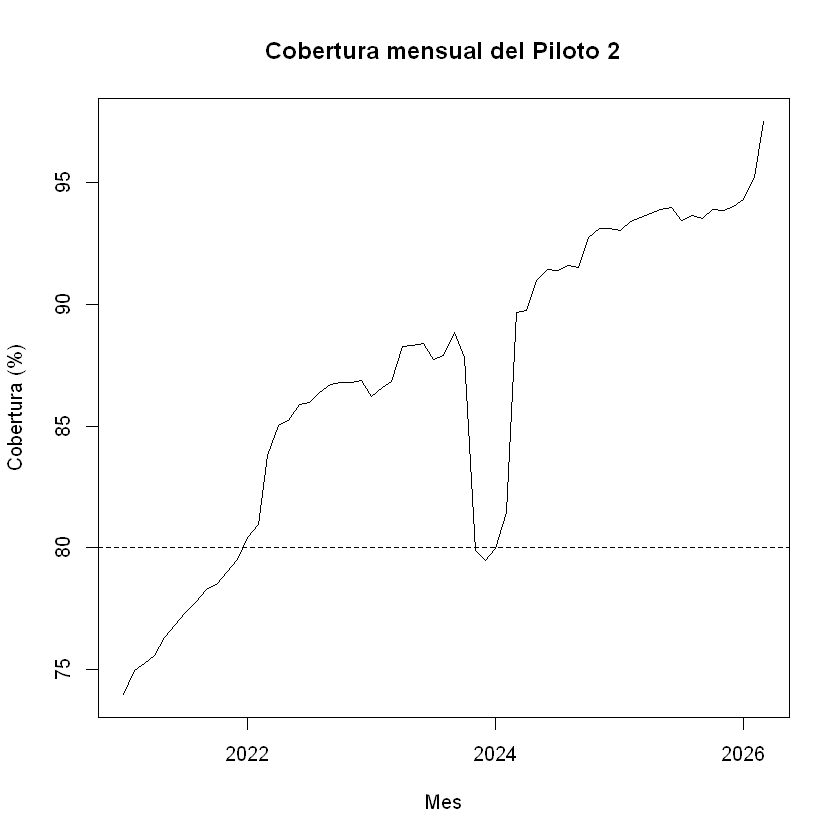

In [65]:
plot(
  monthly_overall_coverage$month,
  monthly_overall_coverage$coverage_pct,
  type = "l",
  xlab = "Mes",
  ylab = "Cobertura (%)",
  main = "Cobertura mensual del Piloto 2"
)

abline(
  h = COVERAGE_THRESHOLD,
  lty = 2
)

In [66]:
# 1. Cobertura máxima y mediana de cada variable Fan Stats
coverage_long <- melt(
  coverage_matrix,
  id.vars = "month",
  variable.name = "variable",
  value.name = "coverage_pct"
)

coverage_long[
  ,
  .(
    primer_mes_con_datos = min(
      month[coverage_pct > 0]
    ),
    cobertura_mediana = median(coverage_pct),
    cobertura_maxima = max(coverage_pct)
  ),
  by = variable
]

variable,primer_mes_con_datos,cobertura_mediana,cobertura_maxima
<fct>,<date>,<dbl>,<dbl>
fan_stats__instagram__followers,2021-01-01,85.2,92.2
fan_stats__spotify__followers,2021-01-01,99.0,99.8
fan_stats__spotify__listeners,2021-01-01,99.0,99.8
fan_stats__tiktok__followers,2021-01-01,46.8,70.2
fan_stats__tiktok__likes,2021-01-01,46.2,69.0
fan_stats__twitter__followers,2021-01-01,75.6,85.8
fan_stats__youtube_artist__monthly_views,2021-01-01,62.6,63.4
fan_stats__youtube_channel__subscribers,2021-01-01,83.2,91.6
fan_stats__youtube_channel__views,2021-01-01,82.6,91.6


In [67]:
# 2. Resumen de la cobertura temporal global
monthly_overall_coverage[
  ,
  .(
    primer_mes = min(month),
    ultimo_mes = max(month),
    cobertura_minima = min(coverage_pct),
    cobertura_mediana = median(coverage_pct),
    cobertura_maxima = max(coverage_pct)
  )
]

primer_mes,ultimo_mes,cobertura_minima,cobertura_mediana,cobertura_maxima
<date>,<date>,<dbl>,<dbl>,<dbl>
2021-01-01,2026-03-01,73.96694,87.73244,97.52066


In [68]:
# 3. Primeros meses que alcanzan 80%
head(
  good_coverage_months,
  12
)

month,series_con_dato,series_esperadas,coverage_pct
<date>,<int>,<int>,<dbl>
2022-01-01,3114,3872,80.42355
2022-02-01,3135,3872,80.96591
2022-03-01,3245,3872,83.80682
2022-04-01,3292,3872,85.02066
2022-05-01,3300,3872,85.22727
2022-06-01,3325,3872,85.87293
2022-07-01,3328,3872,85.95041
2022-08-01,3345,3872,86.38946
2022-09-01,3357,3872,86.69938


In [69]:
# 4. Últimos 24 meses de cobertura temporal
tail(
  monthly_overall_coverage,
  24
)

month,series_con_dato,series_esperadas,coverage_pct
<date>,<int>,<int>,<dbl>
2024-04-01,3475,3872,89.74690
2024-05-01,3523,3872,90.98657
2024-06-01,3540,3872,91.42562
2024-07-01,3539,3872,91.39979
2024-08-01,3546,3872,91.58058
2024-09-01,3544,3872,91.52893
2024-10-01,3591,3872,92.74277
2024-11-01,3606,3872,93.13017
2024-12-01,3606,3872,93.13017


In [71]:
# ============================================================
# DIAGNÓSTICO DE LOS MESES CON MENOR COBERTURA
# desde abril de 2022
# ============================================================

monthly_overall_coverage[
  month >= as.Date("2022-01-01")
][
  order(coverage_pct)
][
  1:15
]

month,series_con_dato,series_esperadas,coverage_pct
<date>,<int>,<int>,<dbl>
2023-12-01,3078,3872,79.49380
2023-11-01,3094,3872,79.90702
2024-01-01,3097,3872,79.98450
2022-01-01,3114,3872,80.42355
2022-02-01,3135,3872,80.96591
2024-02-01,3154,3872,81.45661
2022-03-01,3245,3872,83.80682
2022-04-01,3292,3872,85.02066
2022-05-01,3300,3872,85.22727



## 15. Qué decidir después del Piloto 2

1. desde qué mes existe cobertura cross-artists aceptable;
2. qué variables tienen cobertura suficiente para entrar al clustering;
3. si exigir simultáneamente todas las variables es demasiado restrictivo;
4. cómo tratar `interpolated` y `extrapolated`;
5. profundidad histórica real de Playlist Evolution;
6. tamaño final de la muestra de artistas;
7. estrategia definitiva de almacenamiento antes de escalar a cientos o miles de artistas.



# ATENCION

noviembre 2023–febrero 2024 cae la cobertura global a aproximadamente 81–83% y luego vuelve por encima de 91%. Eso parece más un hueco de datos que una cuestión de adopción de plataformas